This code takes a multi-frame segmented and isolated nucleus z stack tiff along side the original red+green tiff, creates a 3D model for each frame, and measures the volume and surface area.

Set Runtime type to GPU. Run each code block in order.

# Install libraries
---

In [1]:
#!pip uninstall numpy -y
#!pip install numpy==1.26.4
!pip install open3d==0.19.0
!pip install -U tifffile[all]
!pip install -U kaleido==0.2.1
!pip install trimesh==4.6.2
!pip install rtree==1.3.0

# Import libraries


In [2]:
from IPython.display import display
%matplotlib inline
import numpy as np #2.0.2
import matplotlib.pyplot as plt
import cv2
import resource, sys
resource.setrlimit(resource.RLIMIT_STACK, (2**29,-1))
sys.setrecursionlimit(10**6)
import warnings
with warnings.catch_warnings():
  warnings.simplefilter('always')
  import open3d as o3d

import trimesh
from sklearn.cluster import DBSCAN
import plotly.graph_objects as go
import kaleido

import time
import psutil
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)

# Mesh processing

---



In [80]:
#from IPython.display import display
#%matplotlib inline
#import numpy as np
#import matplotlib.pyplot as plt
#import cv2
#import open3d as o3d
#import trimesh
#from sklearn.cluster import DBSCAN
#import plotly.graph_objects as go
#import kaleido
#import resource, sys
#resource.setrlimit(resource.RLIMIT_STACK, (2**29,-1))
#sys.setrecursionlimit(10**6)

def MeshBounds(pcl,xyscale,zscale):#grid of points on the top and bottom layers.
  #get top and bottom slice z position.
  local_points = list(np.asarray(pcl.points))#[[x,y,z],...]
  extra_pcl = o3d.geometry.PointCloud()
  zs=np.asarray(local_points)[:,2]
  #topSlice=local_points[0][2]#safe initial values
  #bottomSlice=local_points[0][2]
  bottomSlice=np.min(zs)
  topSlice=np.max(zs)
  #for i in range(len( local_points )):
    #if(local_points[i][2] > topSlice):
      #topSlice = local_points[i][2]
    #if(local_points[i][2] < bottomSlice):
      #bottomSlice = local_points[i][2]
  #print(topSlice,bottomSlice)
  #We now have the min and max z values.
  for z in [bottomSlice,topSlice]:#for the bottom then top slice
    k = round(z/zscale)
    #extract the layer
    layerPoints=[]#[[x1,y1,z1],[x2,y2,z2],...]
    for i in range(len( local_points )):
      if(local_points[i][2] == z):
        #print("match",local_points[i])
        layerPoints.append(local_points[i])
    #extract the peaks
    layer_pcl = o3d.geometry.PointCloud() #empty point cloud object
    layer_pcl.points = o3d.utility.Vector3dVector(layerPoints)
    layerPoints=list(np.asarray(layerPoints).T)#[[x1,x2,...],[y1,y2,...],[z1,z2,...]]
    labels = np.array(layer_pcl.cluster_dbscan(eps=1, min_points=4, print_progress=False))#label point clusters based on distance
    for group in range(0,labels.max()+1):#for each separate peak
      ind = []
      for i in range(len(labels)):
        if labels[i] == group:
          ind.append(i)
      peak_pcl = layer_pcl.select_by_index(ind)#separate peaks
      binaryPoints = PointCloudToFrame(peak_pcl,xyscale,zscale)

      #add the new points
      for i in range(len(binaryPoints)):#for each x list
        yMin=len(binaryPoints[i])
        yMax=0
        for j in range(len(binaryPoints[i])):#for each y element
          if(binaryPoints[i][j][k]==1):#if its filled with a 1
            if(j<yMin):
              yMin=j
            if(j>yMax):
              yMax=j
        #if( (yMax-yMin)>1 ):#if the points have 1 pixel of space between them
        if( (yMax-yMin)>3 ):#if the points have 3 pixel of space between them
          for j2 in range(yMin+2,yMax-1):#non-inclusive range yMin to yMax
            if(binaryPoints[i][j2][k]==0):
              newPoint = np.asarray([[i*xyscale,j2*xyscale,z]])
              extra_pcl.points.extend(newPoint)
  return(extra_pcl)

def GenerateMesh(frame,xyscale,zscale,modernPointsGroups,modernVoxelGroups):
    """
    Generate a list of triangle meshes and points for each frame.

    Parameters
    ----------
    frame : list
      an array of all pixel intensities from the segmentation of a single frame
    xyscale : float
      pixel width in micrometers
    zscale : float
      pixel height in micrometers

    Returns
    ----------
    mesh : TriangleMesh
      surface mesh reconstruction
    """
    ###spcl,pcl = FrameToPointCloud(frame,xyscale,zscale)
    ###pcls = SeparatePointCloud(pcl)#separated point clouds, 1 or more
    pcls = modernPointsGroups
    #array = GeneratePoints3(frame,xyscale,zscale)
    #pcl = o3d.geometry.PointCloud() #empty point cloud object
    #pcl.points = o3d.utility.Vector3dVector(array)

    #o3d.visualization.draw_plotly([spcl])
    #o3d.visualization.draw_plotly([pcl])
    #surfaceClouds=[]
    #volumePoints = GeneratePointsVolume(frame,xyscale,zscale)
    #print(len(pcl))
    #testclouds = SeparatePointCloud(testcloud)
    #for cloud in pcls:#for each separate nucleus
    #  isolatedFrame = PointCloudToFrame(cloud,xyscale,zscale)#convert the nucleus back to the frame format now that it has been isolated
    #  surfaceClouds.append(  ArrayToPointCloud( GeneratePoints3( isolatedFrame ,xyscale,zscale) )  ) #convert to a point cloud and keep surface points

    mesh = o3d.geometry.TriangleMesh() #empty triangle mesh for all separate nuclei to be added, used for display purposes only
    meshes=[] #list to contain 1 or 2 meshes
    shellPointGroup=[]
    for group in range(len(pcls)):#for each separate nucleus
      #local_pcl = pcls[group]
      local_pcl = ArrayToPointCloud(pcls[group])
      #testframe = PointCloudToFrame(local_pcl,xyscale,zscale)
      testframe = modernVoxelGroups[group]
      array_capped = GeneratePoints3(testframe,xyscale,zscale)
      pcl_capped = o3d.geometry.PointCloud() #empty point cloud object
      pcl_capped.points = o3d.utility.Vector3dVector(array_capped)
      local_mesh = GenerateMeshPoisson(pcl_capped)
      #o3d.visualization.draw_plotly([pcl_capped])
      shellArray = GeneratePoints(testframe,xyscale,zscale)
      shellPoints = o3d.geometry.PointCloud() #empty point cloud object
      shellPoints.points = o3d.utility.Vector3dVector(shellArray)
      #o3d.visualization.draw_plotly([shellPoints])
      #local_mesh = GenerateMeshPoisson(local_pcl)
      #GenerateMeshVoxel(local_pcl)
      #o3d.visualization.draw_plotly([local_mesh])
      #if(local_mesh.is_watertight()==False):#if failed, add extra points to repair the point cloud
      #  extra = MeshBounds(local_pcl,xyscale,zscale)
      #  local_pcl = local_pcl + extra
        #o3d.visualization.draw_plotly([extra])
      #  local_mesh = GenerateMeshPoisson(local_pcl)
      if(local_mesh.is_watertight()==False):#if repair failed, use the convex hull.
      #if(1==1):#if repair failed, use the convex hull.
        #o3d.visualization.draw_plotly([local_mesh])
        print(" - Poisson method failure. Using convex hull")
        local_mesh, _ = local_pcl.compute_convex_hull()
      shellPointGroup.append(shellPoints)
      meshes.append(local_mesh) #append a nucleus to the list for output.
      #mesh = mesh + local_mesh #combine the nuclei for display purposes
      #o3d.visualization.draw_plotly([local_pcl])
    #o3d.visualization.draw_plotly([mesh])#
    #mesh.compute_triangle_normals()
    #draw_geometries([mesh])
    return(meshes,shellPointGroup)

def GenerateMeshPoisson(pcl):
  """
  Generate a triangle mesh using the Poisson method

  Parameters
  ----------
  pcl : PointCloud
     surface points

  Returns
  ----------
  mesh : TriangleMesh
     surface mesh reconstruction
  """
  pcl.normals = o3d.utility.Vector3dVector(np.zeros((1, 3)))  # generate normals
  pcl.estimate_normals()
  pcl.orient_normals_consistent_tangent_plane(20)
  mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcl, depth=4)#4
  return(mesh)

def MeshDeform(mesh):
  vertices = np.asarray(mesh.vertices)
  static_ids = [idx for idx in np.where(vertices[:, 1] < -30)[0]]
  static_pos = []
  for id in static_ids:
    static_pos.append(vertices[id])
  handle_ids = []
  handle_pos = []
  #put a vertex at the top and bottom
  handle_ids = [2490]
  handle_pos = [vertices[2490] + np.array((-40, -40, -40))]
  constraint_ids = o3d.utility.IntVector(static_ids + handle_ids)
  constraint_pos = o3d.utility.Vector3dVector(static_pos + handle_pos)
  with o3d.utility.VerbosityContextManager(
    o3d.utility.VerbosityLevel.Debug) as cm:
    mesh_prime = mesh.deform_as_rigid_as_possible(constraint_ids,constraint_pos,max_iter=50)
  return(mesh_prime)

def ManualMesh(frame,xyscale,zscale):
  surfaceArray,volumeArray = FrameToArray(frame,xyscale,zscale)
  #spcl,pcl = FrameToPointCloud(frame,xyscale,zscale)
  #groups = GroupPoints(surfaceArray)
  groups = [surfaceArray]#REPLACEMENT NEEDED! ADD A REAL 3D GROUPER
  #groups = ClusterArray(surfaceArray)
  groups = ListOfArraysToList(groups)
  #groups = np.asarray(groups)
  #groups = groups.tolist()
  meshes = []
  mesh = o3d.geometry.TriangleMesh() #empty triangle mesh for all separate nuclei to be added, used for display purposes only
  for i in range(len(groups)):
    surfacePtsPerGroup = np.asarray(groups[i])
    local_mesh = ManualMeshHandler(surfacePtsPerGroup,xyscale,zscale)
    #if(local_mesh.is_watertight()==False):#if repair failed, use the convex hull.
    #  local_pcl = ArrayToPointCloud(surfacePtsPerGroup)
    #  local_mesh, _ = local_pcl.compute_convex_hull()
    meshes.append(local_mesh) #append a nucleus to the list for output.
    #mesh = mesh + local_mesh #combine the nuclei for display purposes
  #o3d.visualization.draw_plotly([mesh])
  return(meshes,groups)

def ManualMesh2(surfacePoints,xyscale,zscale):
  #surfacePtsPerGroup = np.asarray(surfacePoints)
  local_mesh = ManualMeshHandler(surfacePoints,xyscale,zscale)
  return(local_mesh)

def GenerateMeshVoxel(pcl):
  N = 2000
  pcl.scale(1 / np.max(pcl.get_max_bound() - pcl.get_min_bound()), center=pcl.get_center())
  pcl.colors = o3d.utility.Vector3dVector(np.random.uniform(0, 1, size=(N, 3)))
  voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcl, voxel_size=0.05)
  o3d.visualization.draw_plotly([voxel_grid])
  #return(voxel_grid)

def MeshToPointCloud(mesh):
  pcl = o3d.geometry.PointCloud() #empty point cloud object
  pcl.points = o3d.utility.Vector3dVector(mesh.vertices)
  #pcl.normals = o3d.utility.Vector3dVector(mesh.normals)
  return pcl

def SeparatePointCloud(pcl):
  pcls = []
  labels = np.array(pcl.cluster_dbscan(eps=0.8, min_points=10, print_progress=False))#label point clusters based on distance, eps=1.5
  max_label = labels.max()
  for group in range(0,max_label+1):#for each separate nucleus
    ind = []
    for i in range(len(labels)):
      if labels[i] == group:
        ind.append(i)
    local_pcl = pcl.select_by_index(ind)#separate the nuclei
    pcls.append(local_pcl)
  return pcls

def draw_geometries(geometries):
  graph_objects = []
  for geometry in geometries:
    geometry_type = geometry.get_geometry_type()
    if geometry_type == o3d.geometry.Geometry.Type.PointCloud:
      points = np.asarray(geometry.points)
      colors = None
      if geometry.has_colors():
        colors = np.asarray(geometry.colors)
      elif geometry.has_normals():
        colors = (0.5, 0.5, 0.5) + np.asarray(geometry.normals) * 0.5
      else:
        geometry.paint_uniform_color((1.0, 0.0, 0.0))
        colors = np.asarray(geometry.colors)
      scatter_3d = go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers', marker=dict(size=1, color=colors))
      graph_objects.append(scatter_3d)
    if geometry_type == o3d.geometry.Geometry.Type.TriangleMesh:
      triangles = np.asarray(geometry.triangles)
      vertices = np.asarray(geometry.vertices)
      colors = None
      if geometry.has_triangle_normals():
        colors = (0.5, 0.5, 0.5) + np.asarray(geometry.triangle_normals) * 0.5
        colors = tuple(map(tuple, colors))
      else:
        colors = (1.0, 0.0, 0.0)
      mesh_3d = go.Mesh3d(x=vertices[:,0], y=vertices[:,1], z=vertices[:,2], i=triangles[:,0], j=triangles[:,1], k=triangles[:,2], facecolor=colors, opacity=1.0)
      graph_objects.append(mesh_3d)
  fig = go.Figure(
    data=graph_objects,
    layout=dict(
      scene=dict(
        xaxis=dict(visible=True),
        yaxis=dict(visible=True),
        zaxis=dict(visible=True),
        aspectmode='cube'
      )
    )
  )
  fig.write_image("fig1.png")
  fig.show()

def O3dToTrimesh(o3dMesh):
  arrVerts = o3dMesh.vertices
  arrFaces = o3dMesh.triangles
  mesh = trimesh.Trimesh(vertices=arrVerts,faces=arrFaces)
  return mesh

def SaveMesh(mesh,name):
    #o3d.io.write_triangle_mesh((name+".obj"), mesh, write_vertex_colors=True)
    o3d.io.write_triangle_mesh((name+".ply"), mesh, write_vertex_colors=True)

# Manual mesh triangulation

In [86]:
def SeparateToIndices(inputList):
  """
  Turn a >1D list into a list of unique elements at axis 1 and a list of indicies which can be used to recreate the original list

  Parameters
  ----------
  inputList : list
    an nD list

  Returns
  ----------
  uniquePoints : list
    list of unique points from inputList
  shapeIndex : list
    a list of indices of uniquePoints which can be used on uniquePoints to get inputList back
  """
  flattenedList = []
  for i in range(len(inputList)):
    for j in range(len(inputList[i])):
      flattenedList.append(inputList[i][j])
  uniquePoints, indexesInverse = np.unique(flattenedList, axis=0, return_inverse=True)
  shapeIndex = indexesInverse.reshape( (len(indexesInverse)//3,3) ).tolist()
  uniquePoints = uniquePoints.tolist()
  return(uniquePoints,shapeIndex)

def IsolateGaps(length, subtract):
  """
  Subtract line segments from a loop and separate disconnected groups.

  Parameters
  ----------
  length : integer
    the list length of a loop of points
  subtract : list
    a 1D list of indexes which are used in line segments to be removed

  Returns
  ----------
  vertGroups : list
    a 2D list of groups of indexes left over from subtraction
  """
  loop = list(range(0,length))
  quadBlocks=[]
  subtract.sort()
  blnWraps=False
  quadBlock=[]
  for i in range(len(subtract)):
    if(subtract[i]==0):
      if(subtract[-1]==length-1):#if the block wraps
        blnWraps=True
      quadBlock.append(subtract[i])
      if(subtract[i+1]-subtract[i]!=1):#discontinuous
        quadBlocks.append(quadBlock)
        quadBlock=[]
    elif(subtract[i]==length-1):
      quadBlock.append(subtract[i])
      quadBlocks.append(quadBlock)
    else:
      if(subtract[i+1]-subtract[i]==1):#continuous
        quadBlock.append(subtract[i])
      else:#break
        quadBlock.append(subtract[i])
        quadBlocks.append(quadBlock)
        quadBlock=[]
  if(blnWraps==True):
    quadBlocks[0]=quadBlocks[-1]+quadBlocks[0]
    quadBlocks.pop(-1)
  vertGroups=[]#subtract is now grouped, use it to split loop
  first=0
  last=0
  blnWraps=True
  if(quadBlocks[0][0]==0 and quadBlocks[-1][-1]==length-1):
    blnWraps=False
  for i in range(len(quadBlocks)):
    for j in range(len(quadBlocks[i])):
      if(j==0):
        last=quadBlocks[i][j]
      elif(j==len(quadBlocks[i])-1):
        vertGroups.append(loop[first:last+1])
        first=quadBlocks[i][j]
  vertGroups.append(loop[first:last+1])
  if(blnWraps==True):
    vertGroups[0]=loop[quadBlocks[-1][-1]::1] + vertGroups[0]
  return(vertGroups)

def ArraysToMesh(coordPoints,coordTris):
  indTris = EmptyArray([len(coordTris),3]) #number of triangles by 3 points in each
  for i in range(len(coordTris)):
    for j in range(3):
      tempIndex = None
      for k in range(len(coordPoints)):
        coordTrisTemp = np.asarray(coordTris[i][j])
        coordPointsTemp = np.asarray(coordPoints)[k]
        if( coordPointsTemp[0] == coordTrisTemp[0] and coordPointsTemp[1] == coordTrisTemp[1] and coordPointsTemp[2] == coordTrisTemp[2] ):
          tempIndex = k
          break
      indTris[i][j] = tempIndex #each point as an index for coordPoints in the location from coordTris
  coordPoints = np.asarray(coordPoints)
  indTris = np.asarray(indTris)
  coordPoints = o3d.utility.Vector3dVector(coordPoints)
  indTris = o3d.utility.Vector3iVector(indTris)
  outputMesh = o3d.geometry.TriangleMesh(coordPoints, indTris)
  return(outputMesh)

def TrianglesToMesh(coordTris):
  coordPoints,indTris = SeparateToIndices(coordTris)
  coordPoints = np.asarray(coordPoints)
  indTris = np.asarray(indTris)
  coordPoints = o3d.utility.Vector3dVector(coordPoints)
  indTris = o3d.utility.Vector3iVector(indTris)
  outputMesh = o3d.geometry.TriangleMesh(coordPoints, indTris)
  return(outputMesh)

def GroupPoints(points):
  """
  Group points by continuity.

  Parameters
  ----------
  points : list
    a 2D list of ungrouped coordinates from a single layer

  Returns
  ----------
  groups : ndarray
    an array of groups of coordinate points
  """
  groupId = np.asarray(range(len(points)))
  for i in range(len(points)):
    targets=[]
    for j in range(len(points)):
      if( abs(points[j][0]-points[i][0])<=1 and abs(points[j][1]-points[i][1])<=1 and points[j]!=points[i]):#if points are unique neighbors on the grid, both diagonal and orthogonal
        targets.append(groupId[j])
    for j in range(len(points)):
      if(j!=i):
        for target in targets:
          if(groupId[j]==target):
            groupId[j]=groupId[i]
  groups = SplitByLabel(np.asarray(points),np.asarray(groupId))
  return(groups)

def TraceConcavePolygon(pts):
  """
  Order points around the perimeter.
  Can be clockwise or counter-clockwise.

  Parameters
  ----------
  pts : ndarray
    a 2D list of coordinates from a single layer

  Returns
  ----------
  ordered : list
    points from pts sorted along the perimeter
  """
  ordered = [list(pts[0])]#starting with only the first point
  remaining = pts.tolist()
  cursor = list(pts[0])
  for i in range(1,len(pts)):#for each new point
    closest = remaining#find two closest
    closest.sort(key = lambda K: (K[0]-cursor[0])**2 + (K[1]-cursor[1])**2)#sort by proximity to point i
    closest = closest[0:2]#2 closest points to i
    if (i>0):#if not the first of the layer
      if(closest[0] not in ordered):#if neighbor 0 is unused, use it
        cursor=closest[0]
      elif(closest[1] not in ordered):#if neighbor 1 is unused, use it
        cursor=closest[1]
    remaining.remove(cursor)
    ordered.append(cursor)
  return(ordered)

def SegmentNormals(allPoints):
  """
  Find tangent vectors for an ordered loop of points (normals of line segments)

  Parameters
  ----------
  allPoints : ndarray
    a 2D list of coordinates from a single layer

  Returns
  ----------
  flatPairs : list
    a list of paired indexes from the layer which have been deemed flat
  normals : list
    a list of normals for pairs in flatPairs. 0← 1↓ 2→ 3↑
  """
  flatPairs = []
  normals = []
  for i in range(0,len(allPoints)):
    if(allPoints[i-1][0]==allPoints[i][0]):#same x
      flatPairs.append([i-1,i])
      if(allPoints[i-1][1]<allPoints[i][1]):#growing y
        #look for the corresponding place in layer2 if it exists
        normals.append(0)#ccw so look from the +x
        #plt.plot(allPoints[i-1:i+1,0],allPoints[i-1:i+1,1],'ro')
      else:#shrinking y
        normals.append(2)#look from the -x
        #plt.plot(allPoints[i-1:i+1,0],allPoints[i-1:i+1,1],'mo')
    if(allPoints[i-1][1]==allPoints[i][1]):#same y
      flatPairs.append([i-1,i])
      if(allPoints[i-1][0]<allPoints[i][0]):#growing x
        normals.append(3)#look from the -y
        #plt.plot(allPoints[i-1:i+1,0],allPoints[i-1:i+1,1],'go')
      else:#shrinking x
        normals.append(1)#look from the +y
        #plt.plot(allPoints[i-1:i+1,0],allPoints[i-1:i+1,1],'co')
  return(flatPairs,normals)

def NeighborPoints(layer1,layer2,normals1,normals2,flatIndL1,flatIndL2,i,p):
  """
  Find the layer2 point opposite to the point p at pair index i in flatInd1

  Parameters
  ----------
  layer1 : ndarray
    a 2D list of coordinates from layer 1
  layer2 : ndarray
    a 2D list of coordinates from layer 2
  normals1 : array-like
    a list of normals for pairs in flatIndL1
  normals2 : array-like
    a list of normals for pairs in flatIndL2
  flatIndL1 : array-like
    a list of paired indexes from layer 1 which have been deemed flat
  flatIndL2 : array-like
    a list of paired indexes from layer 2 which have been deemed flat
  i : integer
    the index of flatIndL1 associated with the index of the layer 1 point of interest
  p : integer
    if the first or second point from a pair should be inspected

  Returns
  ----------
  opposites : list
    a pair of indices of opposites. the layer 1 point then the layer 2 point. Indexes are for layer1 and layer2
  """
  normal = normals1[i]#find everything along the normal, don't filter by direction yet
  candidatesL1=[]
  candidatesL2=[]
  if(normal == 0 or normal == 2):#along x, same y
    for j in range(len(flatIndL2)):
      if(layer2[flatIndL2[j][p]][1]==layer1[flatIndL1[i][p]][1]):
        candidatesL2.append(flatIndL2[j][p])
    for j in range(len(flatIndL1)):
      if(layer1[flatIndL1[j][p]][1]==layer1[flatIndL1[i][p]][1]):
        candidatesL1.append(flatIndL1[j][p])
  else:#along y, same x
    for j in range(len(flatIndL2)):
      if(layer2[flatIndL2[j][p]][0]==layer1[flatIndL1[i][p]][0]):
        candidatesL2.append(flatIndL2[j][p])
    for j in range(len(flatIndL1)):
      if(layer1[flatIndL1[j][p]][0]==layer1[flatIndL1[i][p]][0]):
        candidatesL1.append(flatIndL1[j][p])
  pairs =[]#group them by proximity, only keep the one close to point i; we will come back later for the rest.
  if(len(candidatesL1)<len(candidatesL2)):
    for k in range(len(candidatesL1)):
      dist=[]
      for j in range(len(candidatesL2)):
        dist.append( abs(layer1[candidatesL1[k]][0] - layer2[candidatesL2[j]][0]) + abs(layer1[candidatesL1[k]][1] - layer2[candidatesL2[j]][1]) )
      pairs.append([k,np.argmin(dist)])
  else:
    for j in range(len(candidatesL2)):
      dist=[]
      for k in range(len(candidatesL1)):
        dist.append( abs(layer1[candidatesL1[k]][0] - layer2[candidatesL2[j]][0]) + abs(layer1[candidatesL1[k]][1] - layer2[candidatesL2[j]][1]) )
      pairs.append([np.argmin(dist),j])
  pairs = np.asarray(pairs)#we have matching opposite points, now make sure that their adjacent points are also opposite
  opposites = []
  for k in range(len(pairs)):#given the pairs, iterate through them for translation and display
    if( candidatesL1[pairs[k][0]]== flatIndL1[i][p] ):#if the pair includes the vertex of interest
      #cand:index of layer2   #flatIndL2: index of layer2 #pairs: indexes of cand #given index of pairs, find index of flat #get index of layer2, reverse it to find which flat contains it
      layer2Index = candidatesL2[pairs[k][1]]#take only the ind1 from flatIndL2
      flatIndex2 = np.asarray(flatIndL2).T.tolist()[p].index(layer2Index)
      layer1Index = candidatesL1[pairs[k][0]]
      flatIndex1 = np.asarray(flatIndL1).T.tolist()[p].index(layer1Index)
      if(normals1[i] == normals2[flatIndex2]):#finally check the normals
        opposites.append([candidatesL1[pairs[k][0]],candidatesL2[pairs[k][1]]])
  return(opposites)

def BasicTriangleFill(layer1,layer2):
  triangles = []
  if(len(layer1) == 0 or len(layer2) ==0):
    print("Tried to fill empty layers")
    #return([])
  if(len(layer1) == len(layer2)):
    for i in range(1,len(layer1)):
      triangles.append([layer1[i-1], layer2[i-1], layer1[i]])
      triangles.append([layer1[i], layer2[i], layer2[i-1]])
  else:
    for i in range(1, max( len(layer1), len(layer2) )):
      if(i>=len(layer1)):
        for j in range(i,len(layer2)):
          triangles.append([layer1[i-1], layer2[j-1], layer2[j]])
        break
      elif(i>=len(layer2)):
        for j in range(i,len(layer1)):
          triangles.append([layer2[i-1], layer1[j-1], layer1[j]])
        break
      else:
        triangles.append([layer1[i-1], layer2[i-1], layer1[i]])
        triangles.append([layer1[i], layer2[i], layer2[i-1]])
  return(triangles)

def TriangulatePolygon(layer1,layer2):
  #take the two loops #find places with horizontal lines. #fill them in as quads #find the remaining regions, separate them out into independent lists
  #loop through those places with fan fills where needed, ie. if the # of points on the top and bottom don't match. #have them both be ccw
  #lists for two neighboring points and the normal between them.
  trimLayer1=[]
  trimLayer2=[]
  #plt.plot(layer1[:,0],layer1[:,1],'go')
  #plt.plot(layer2[:,0],layer2[:,1],'bo')
  #for i in range(len(layer1)):
  #  plt.arrow(layer1[i-1][0],layer1[i-1][1],layer1[i][0]-layer1[i-1][0],layer1[i][1]-layer1[i-1][1],width=.2,edgecolor='blue',facecolor='blue')
  #for i in range(len(layer2)):
  #  plt.arrow(layer2[i-1][0],layer2[i-1][1],layer2[i][0]-layer2[i-1][0],layer2[i][1]-layer2[i-1][1],width=.2,edgecolor='green',facecolor='green')

  #plt.plot(layer1[:,0],layer1[:,1],'ko')
  #plt.plot(layer2[:,0],layer2[:,1],'ko')
  flatIndL1,normals1 = SegmentNormals(layer1)
  flatIndL2,normals2 = SegmentNormals(layer2)
  triangles=[]
  breaksLayer1 = []
  breaksLayer2 = []
  segmentsLayer1 = np.dstack(( np.arange(len(layer1)) , np.roll(np.arange(len(layer1)),-1 )  ))
  segmentsLayer2 = np.dstack(( np.arange(len(layer2)) , np.roll(np.arange(len(layer2)),-1 )  ))
  trimSegmentsLayer1 = []
  trimSegmentsLayer2 = []
  segmentGroups = []
  segmentGroup = []
  blnPrevInQuad = False
  blnInQuad = False
  blnFirstIn = False #if the first point has a quad
  firstIndexes = []
  lastP1Ind = 0
  lastP3Ind = 0
  lastP2Ind = 0
  lastP4Ind = 0
  print("\r"+"Triangulating Polygons", end='')
  #print('-')
  process = psutil.Process()
  #print(process.memory_info().rss)
  #time.sleep(0.1)#sleep in seconds
  for i in range(len(layer1)):
    print("\r"+"l1:"+str(i), end='')
    #time.sleep(0.01)#sleep in seconds
    blnInQuad = False
    if(i in np.asarray(flatIndL1).T[0].tolist()):
      print("\r"+"NeightborPoints 1", end='')
      #time.sleep(0.01)#sleep in seconds
      opposites = NeighborPoints(layer1,layer2,normals1,normals2,flatIndL1,flatIndL2,np.asarray(flatIndL1).T[0].tolist().index(i),0)
      if(opposites != []):
        print("\r"+"NeightborPoints 2", end='')
        #time.sleep(0.01)#sleep in seconds
        flatIndex2 = np.asarray(flatIndL2).T.tolist()[0].index(opposites[0][1])#location of opposite 1 in flatIndL2
        opposites2 = NeighborPoints(layer1,layer2,normals1,normals2,flatIndL1,flatIndL2,np.asarray(flatIndL1).T[0].tolist().index(i),1)
        if(opposites2 != []):#index of 4th from algorithm and from cross referencing the 3rd
          if(opposites2[0][1]==flatIndL2[flatIndex2][1]):#successfully found an appropriate quad
            print("\r"+"Found Quad", end='')
            #time.sleep(0.01)#sleep in seconds
            P1=layer1[opposites[0][0]]
            P3=layer2[opposites[0][1]]
            P2=layer1[opposites2[0][0]]
            P4=layer2[opposites2[0][1]]
            lastP2Ind = opposites2[0][0]
            lastP4Ind = opposites2[0][1]
            lastP1Ind = opposites[0][0]
            lastP3Ind = opposites[0][1]
            #plt.arrow(P1[0],P1[1],P3[0]-P1[0],P3[1]-P1[1],width=.2,edgecolor='green',facecolor='green')
            #plt.arrow(P2[0],P2[1],P4[0]-P2[0],P4[1]-P2[1],width=.2,edgecolor='green',facecolor='green')
            #plt.arrow(P3[0],P3[1],P1[0]-P3[0],P1[1]-P3[1],width=.2,edgecolor='green',facecolor='green')
            #plt.arrow(P4[0],P4[1],P2[0]-P4[0],P2[1]-P4[1],width=.2,edgecolor='green',facecolor='green')
            trimLayer1.append(opposites[0][0])
            trimLayer1.append(opposites2[0][0])
            trimLayer2.append(opposites[0][1])
            trimLayer2.append(opposites2[0][1])
            triangles.append([P1,P2,P3])
            triangles.append([P2,P3,P4])
            trimSegmentsLayer1 = []
            trimSegmentsLayer2 = []
            print("\r"+"Quad Made into Tris", end='')
            #splitting up the remaining unused points into subsections for fan filling.
            #time.sleep(0.01)#sleep in seconds
            if(firstIndexes == []):
              firstIndexes = [lastP1Ind,lastP3Ind]
            if(i == 0):
              blnFirstIn = True
            if(blnPrevInQuad==False):#entering a quad
              if(breaksLayer1 != []):
                if(breaksLayer2[-1] < lastP3Ind):
                  segmentGroup = [ list(range(breaksLayer1[-1], lastP1Ind+1)), list(range(breaksLayer2[-1], lastP3Ind+1)) ]
                else: #fix layer 2 looping
                  segmentGroup = [ list(range(breaksLayer1[-1], lastP1Ind+1)), list(range(breaksLayer2[-1],len(layer2)))+list(range(0,lastP3Ind+1)) ]
              breaksLayer1.append(lastP1Ind)
              breaksLayer2.append(lastP3Ind)
            if(i==len(layer1)-1):#on last iteration
              print("\r"+"Last Iteration", end='')
              #time.sleep(0.01)#sleep in seconds
              breaksLayer1.append(lastP2Ind)
              breaksLayer2.append(lastP4Ind)
            if(segmentGroup != []):#dump the section to segmentGroups
              print("\r"+"Dumping Segmentation", end='')
              #time.sleep(0.01)#sleep in seconds
              segmentGroups.append(segmentGroup)
              segmentGroup = []
            blnInQuad = True
    if(blnInQuad==False):
      if(blnPrevInQuad==True):#exiting a quad
        breaksLayer1.append(lastP2Ind)
        breaksLayer2.append(lastP4Ind)
    blnPrevInQuad = blnInQuad
  if(blnPrevInQuad == False):
    if(len(breaksLayer2)>0):
      if(breaksLayer2[-1] < breaksLayer2[0]):#if looped around
        segmentGroup = [ list(range(breaksLayer1[-1], len(layer1))) + list(range(0, breaksLayer1[0]+1)), list(range(breaksLayer2[-1], breaksLayer2[0]+1)) ]
      else: #fix layer 2 looping
        segmentGroup = [ list(range(breaksLayer1[-1], len(layer1))) + list(range(0, breaksLayer1[0]+1)), list(range(breaksLayer2[-1],len(layer2)))+list(range(0,breaksLayer2[0]+1)) ]
  elif(blnFirstIn == False):#first was not a quad
    return(0)
    if(breaksLayer2[-1] < breaksLayer2[0]):
      segmentGroup = [ list(range(breaksLayer1[-1], breaksLayer1[0]+1)), list(range(breaksLayer2[-1], breaksLayer2[0]+1)) ]
    else: #fix layer 2 looping
      segmentGroup = [ list(range(breaksLayer1[-1], breaksLayer1[0]+1)), list(range(breaksLayer2[-1],len(layer2)))+list(range(0,breaksLayer2[0]+1)) ]
  if(segmentGroup != []):#dump the section to segmentGroups
    segmentGroups.append(segmentGroup)
  triangles = np.asarray(triangles).tolist()
  #displayTriangles = np.asarray(triangles).tolist()
  for localGroup in segmentGroups:
    localLayer1 = layer1[localGroup[0]]
    localLayer2 = layer2[localGroup[1]]
    print("\r"+"BasicTriangleFill", end='')
    #time.sleep(0.1)#sleep in seconds
    localTris = BasicTriangleFill(localLayer1,localLayer2)
    triangles = triangles + localTris
  if(triangles == []):#if everything went wrong and there are no triangle, fan fill everything
    mergedLayer = np.concatenate((layer1,layer2))
    localTris = ConcaveMarch(mergedLayer)
    #localTris = BasicTriangleFill(layer1,layer2)
    triangles = triangles + localTris
  #plt.show()
  #tempname="figC"+str(len(triangles))+".svg"
  #print(tempname)
  #print(tempname)
  #plt.savefig(tempname)
  #plt.clf()
  #plt.show()
  #for i in range(len(displayTriangles)):
  #  localPoints=displayTriangles[i]
  #  localPoints = np.asarray(localPoints).T
  #  plt.fill(localPoints[0], localPoints[1])

  #for i in breaksLayer1:
  #  plt.plot(layer1[i,0],layer1[i,1],'yx')
  #for i in breaksLayer2:
  #  plt.plot(layer2[i,0],layer2[i,1],'yx')
  #plt.savefig(tempname)
  #plt.show()
  #time.sleep(0.1)#sleep in seconds
  #print("")
  #print("Exit TriangulatePolygon")
  #time.sleep(0.1)#sleep in seconds
  return(triangles)#end TriangulatePolygon

def ComparePixelMasks(inputMask, templateMask, outputMask = None):
  """
  Match two 2D lists by some combinations of rotations and flips. If given a third list, it will return it with the transforms as the template.

  Parameters
  ----------
  inputMask : array-like
    a 2D list
  inputMask : array-like
    a 2D list to be matched to the inputMask
  outputMask : array-like
    a 2D list associated with the template to be transformed to fit the input

  Returns
  ----------
  MatchFound : boolean
    if the template can be made to match the input
  outputMask : array-like
    a 2D array-like of its original type, tranformed with the template if a match was found
  """
  if isinstance(inputMask, list):
    inputMask = np.asarray(inputMask)
  if isinstance(templateMask, list):
    templateMask = np.asarray(templateMask)
  outputAsList = False
  if(outputMask is not None ):
    if isinstance(outputMask, list):
      outputAsList = True
      outputMask = np.asarray(outputMask)
  templateMasks = [templateMask, np.fliplr(templateMask)]
  for flipped in [0,1]:
    for ccwTurns in range(0,4):
      if(  np.array_equal(inputMask, np.rot90(templateMasks[flipped],ccwTurns) ) ):
        if(outputMask is not None ):
          if(flipped):
            outputMask = np.fliplr(outputMask)
          outputMask = np.rot90(outputMask,ccwTurns)
          if(outputAsList):
            outputMask = outputMask.tolist()
        return(True, outputMask)
  return(False, outputMask)

def bresenham(pointA,pointB):
  dx=int(pointB[0]-pointA[0])
  dy=int(pointB[1]-pointA[1])
  horiz = np.sign(dx)
  vert = np.sign(dy)
  points=[]
  if(dx==0 and dy==0):
    pass
  elif(dx==0):
    for y in range(0,abs(dy)+1):
      points.append([pointA[0],pointA[1]+vert*y,pointA[2]])
  elif(dy==0):
    for x in range(0,abs(dx)+1):
      points.append([pointA[0]+horiz*x,pointA[1],pointA[2]])
  else:
    x1,y1 = 0,0
    x2,y2 = abs(dx),abs(dy)
    if(x2>=y2):
      m_new = 2 * (y2 - y1)
      slope_error_new = m_new - (x2 - x1)
      y = y1
      for x in range(x1, x2+1):
        points.append([pointA[0]+horiz*x,pointA[1]+vert*y,pointA[2]])
        slope_error_new = slope_error_new + m_new
        if (slope_error_new >= 0):
          y = y+1
          slope_error_new = slope_error_new - 2 * (x2 - x1)
    else:
      m_new = 2 * (x2 - x1)
      slope_error_new = m_new - (y2 - y1)
      x = x1
      for y in range(y1, y2+1):
        points.append([pointA[0]+horiz*x,pointA[1]+vert*y,pointA[2]])
        slope_error_new = slope_error_new + m_new
        if (slope_error_new >= 0):
          x = x+1
          slope_error_new = slope_error_new - 2 * (y2 - y1)
  return(points)

def PairLayerGroups(l1Groups,l2Groups):
  """
  Pairs up which groups should be connected to eachother.

  Parameters
  ----------
  l1Groups : list
    one or more lists of points from layer 1.
  l2Groups : list
    one or more lists of points from layer 2.

  Returns
  ----------
  pairs : list
    a list of pairs of layer group points [[A,B],[C,D]] or [[A,B],[C]] or [[A,B],[D]] or [[A,B]] shape:(1/2,1/2 inhomogenous)
    [[l1g1,l2g1/2],[l1g2,l2g2/1]]
  pairTriangles : list
    correction triangles for when a layer needs to be bisected
  trackPairs : list
    list of form [case#, [l1g#,l2g#], [l1g#,l2g#]] where the last pair can have None for both or either l#g#
  """
  print("\r"+"PairLayerGroups", end='')
  if( len(l1Groups)==0 or len(l1Groups[0])==0 or len(l2Groups)==0 or len(l2Groups[0])==0 ):
    print(" - Error")
  print("\r"+"PairLayerGroups Data Validated", end='')
  pairTriangles = []
  boundsL1 = EmptyArray([2,2]) #[[xmin,xmax],[ymin,ymax]] #group by proximity
  boundsL2 = EmptyArray([2,2])
  avgL1 = [] #[[avgx,avgy]] or [[avgx_g1,avgy_g1],[avgx_g2,avgy_g2]]
  avgL2 = []
  medianL1 = [] #[[avgx,avgy]] or [[avgx_g1,avgy_g1],[avgx_g2,avgy_g2]]
  medianL2 = []
  pairs = []# [[A,B],[C,D]] or [[A,B],[C]] or [[A,B],[D]] or [[A,B]]
  trackPairs = EmptyArray([2,2]) #[ case, [l1g#,l2g#], [l1g#,l2g#] ]
  distances = EmptyArray([len(l1Groups),len(l2Groups)])
  hullAreasL1 = []
  hullAreasL2 = []
  print("\r"+"Getting Layer Group Bound + Dist Info", end='')
  for i in range(len(l1Groups)):
    tempX,tempY = np.asarray(l1Groups[i]).T[:-1]
    minX,maxX = (min(tempX), max(tempX))
    minY,maxY = (min(tempY), max(tempY))
    boundsL1 = [[min(list(filter(None,[boundsL1[0][0],minX]))), max(list(filter(None,[boundsL1[0][1],maxX])))],[min(list(filter(None,[boundsL1[1][0],minY]))), max(list(filter(None,[boundsL1[1][1],maxY])))]]
    avgL1.append([np.mean(tempX),np.mean(tempY)])
    medianL1.append([(maxX-minX)/2+minX,(maxY-minY)/2+minY])
    hullAreasL1.append(np.abs((maxX-minX)*(maxY-minY)))
  for i in range(len(l2Groups)):
    tempX,tempY = np.asarray(l2Groups[i]).T[:-1]
    minX,maxX = (min(tempX), max(tempX))
    minY,maxY = (min(tempY), max(tempY))
    boundsL2 = [[min(list(filter(None,[boundsL1[0][0],minX]))), max(list(filter(None,[boundsL1[0][1],maxX])))],[min(list(filter(None,[boundsL1[1][0],minY]))), max(list(filter(None,[boundsL1[1][1],maxY])))]]
    avgL2.append([np.mean(tempX),np.mean(tempY)])
    medianL2.append([(maxX-minX)/2+minX,(maxY-minY)/2+minY])
    hullAreasL2.append(np.abs((maxX-minX)*(maxY-minY)))
  for i in range(len(l1Groups)):
    for j in range(len(l2Groups)):
      distances[i][j] = abs(avgL1[i][0]-avgL2[j][0]) + abs(avgL1[i][1]-avgL2[j][1]) #distance approximation [[,],[,]] or [[],[]] or [[,]]
      #distances[i][j] = abs(medianL1[i][0]-medianL2[j][0]) + abs(medianL1[i][1]-medianL2[j][1]) #distance approximation [[,],[,]] or [[],[]] or [[,]]
  print("\r"+"Pairing Groups", end='')
  blnSoloPeak1 = False
  blnSoloPeak2 = False
  soloPeakTuning = 0.3#0.2
  #print("len l1",len(l1Groups),"len l2",len(l2Groups))
  if(len(l1Groups) != len(l2Groups)):
    boundsRelL1 = np.subtract(boundsL1, [ [abs(boundsL2[0][1]-boundsL2[0][0]),abs(boundsL2[0][1]-boundsL2[0][0])],[abs(boundsL2[1][1]-boundsL2[1][0]),abs(boundsL2[1][1]-boundsL2[1][0])] ] )
    boundsRelL2 = np.subtract(boundsL2, [ [abs(boundsL1[0][1]-boundsL1[0][0]),abs(boundsL1[0][1]-boundsL1[0][0])],[abs(boundsL1[1][1]-boundsL1[1][0]),abs(boundsL1[1][1]-boundsL1[1][0])] ] )
    if(len(l1Groups) == 1):#interior and exterior bound within threshold
      blnSoloPeak1 = abs(distances[0][0] - distances[0][1])/(distances[0][0] + distances[0][1]) > soloPeakTuning
      if (blnSoloPeak1 and hullAreasL1[0] > hullAreasL2[0]+hullAreasL2[1]):
        blnSoloPeak1 = False
    else:
      blnSoloPeak2 = abs(distances[0][0] - distances[1][0])/(distances[0][0] + distances[1][0]) > soloPeakTuning
      if (blnSoloPeak2 and hullAreasL2[0] > hullAreasL1[0]+hullAreasL1[1]):
        blnSoloPeak2 = False
  elif(len(l1Groups) == 1):#for case 4 detection
    if(hullAreasL2 > hullAreasL1 and distances[0][0] > np.sqrt(hullAreasL2)/4 and np.sqrt(hullAreasL1) < 2/3*np.sqrt(hullAreasL2) ):
      blnSoloPeak1 = True
    elif(hullAreasL1 > hullAreasL2 and distances[0][0] > np.sqrt(hullAreasL1)/4 and np.sqrt(hullAreasL2) < 2/3*np.sqrt(hullAreasL1) ):
      blnSoloPeak2 = True

  # Begin testing which case the pair falls under
  if(blnSoloPeak1 == False and blnSoloPeak2 == False and len(l1Groups)==1 and len(l2Groups)==1 and len(l1Groups)+len(l2Groups)==2):# case 1 and 2
    print("\r"+"Layer Case 1 or 2", end='')
    pairs = [[l1Groups[0],l2Groups[0]]]
    trackPairs =[1,[0,0],[None,None]]
  elif(blnSoloPeak1 == False and blnSoloPeak2 == False and len(l1Groups)+len(l2Groups)==3):# case 3
    print("\r"+"Layer Case 3", end='')
    if(len(l1Groups)==1):
      l1Groups, pairTriangles = BisectLayer(l1Groups[0])
    if(len(l2Groups)==1):
      l2Groups, pairTriangles = BisectLayer(l2Groups[0])
    #avgL1 = []
    #avgL2 = []
    #for i in range(len(l1Groups)):
    #  tempX,tempY = np.asarray(l1Groups[i]).T[:-1]
    #  boundsL1 = [[min(list(filter(None,[boundsL1[0][0],min(tempX)]))), max(list(filter(None,[boundsL1[0][1],max(tempX)])))],[min(list(filter(None,[boundsL1[1][0],min(tempY)]))), max(list(filter(None,[boundsL1[1][1],max(tempY)])))]]
    #  avgL1.append([np.mean(tempX),np.mean(tempY)])
    #for i in range(len(l2Groups)):
    #  tempX,tempY = np.asarray(l2Groups[i]).T[:-1]
    #  boundsL2 = [[min(list(filter(None,[boundsL1[0][0],min(tempX)]))), max(list(filter(None,[boundsL1[0][1],max(tempX)])))],[min(list(filter(None,[boundsL1[1][0],min(tempY)]))), max(list(filter(None,[boundsL1[1][1],max(tempY)])))]]
    #  avgL2.append([np.mean(tempX),np.mean(tempY)])
    #distances = EmptyArray([len(l1Groups),len(l1Groups)])
    #for i in range(len(l1Groups)):
    #  for j in range(len(l2Groups)):
    #    distances[i][j] = abs(avgL1[i][0]-avgL2[j][0]) + abs(avgL1[i][1]-avgL2[j][1]) #distance approximation [[,],[,]] or [[],[]] or [[,]]
    pairs = [[None,None],[None,None]]
    pairs[0][0] = l1Groups[0]#given this is case3 we set these up.
    pairs[1][0] = l1Groups[1]
    if(distances[0][0] <= distances[0][-1]): #layer1 group1 to layer2 group1 distance is <= to layer1 group1 to layer2 group 2 distance. This sorts the 4 total loops into 2 pairs based on which ones are closest.
      pairs[0][1] = l2Groups[0]#pair l2g1 with l1g1
      pairs[1][1] = l2Groups[-1]
      trackPairs =[3,[0,0],[1,1]]#case3, [l1g1,l2g1], [l1g2,l2g2]
    else:
      pairs[0][1] = l2Groups[-1]#pair l2g2 with l1g1
      pairs[1][1] = l2Groups[0]
      trackPairs =[3,[0,1],[1,0]]#case3, [l1g1,l2g2], [l1g2,l2g1]
  elif( (blnSoloPeak1 or blnSoloPeak2) and (len(l1Groups)==1 and len(l2Groups)==1) and len(l1Groups)+len(l2Groups)==2):# case 4
    print("\r"+"Layer Case 4", end='')
    if(blnSoloPeak2):
      l1Groups, pairTriangles = BisectLayer(l1Groups[0])
    if(blnSoloPeak1):
      l2Groups, pairTriangles = BisectLayer(l2Groups[0])
    #avgL1 = []
    #avgL2 = []
    #print("bisection done")
    #for i in range(len(l1Groups)):
    #  tempX,tempY = np.asarray(l1Groups[i]).T[:-1]
    #  boundsL1 = [[min(list(filter(None,[boundsL1[0][0],min(tempX)]))), max(list(filter(None,[boundsL1[0][1],max(tempX)])))],[min(list(filter(None,[boundsL1[1][0],min(tempY)]))), max(list(filter(None,[boundsL1[1][1],max(tempY)])))]]
    #  avgL1.append([np.mean(tempX),np.mean(tempY)])
    #for i in range(len(l2Groups)):
    #  tempX,tempY = np.asarray(l2Groups[i]).T[:-1]
    #  boundsL2 = [[min(list(filter(None,[boundsL1[0][0],min(tempX)]))), max(list(filter(None,[boundsL1[0][1],max(tempX)])))],[min(list(filter(None,[boundsL1[1][0],min(tempY)]))), max(list(filter(None,[boundsL1[1][1],max(tempY)])))]]
    #  avgL2.append([np.mean(tempX),np.mean(tempY)])
    #distances = EmptyArray([len(l1Groups),len(l1Groups)])
    #for i in range(len(l1Groups)):
    #  for j in range(len(l2Groups)):
    #    distances[i][j] = abs(avgL1[i][0]-avgL2[j][0]) + abs(avgL1[i][1]-avgL2[j][1]) #distance approximation [[,],[,]] or [[],[]] or [[,]]
    if(len(l1Groups) == 1): # [[,]] layer 1 is a solo peak
      #print("l1")
      pairs = [[None,None],[None]]
      pairs[0][0] = l1Groups[0]
      if(distances[0][0] <= distances[0][-1]):
        pairs[0][1] = l2Groups[0]
        pairs[1][0] = l2Groups[-1]
        trackPairs =[4,[0,0],[None,1]]
      else:
        pairs[0][1] = l2Groups[-1]
        pairs[1][0] = l2Groups[0]
        trackPairs =[4,[0,1],[None,0]]
    elif(len(l2Groups) == 1): # [[],[]] layer 2 is a solo peak
      #print("l2")
      pairs = [[None,None],[None]]
      pairs[0][1] = l2Groups[0]
      if(distances[0][0] <= distances[-1][0]):
        pairs[0][0] = l1Groups[0]
        pairs[1][0] = l1Groups[-1]
        trackPairs =[4,[0,0],[1,None]]
      else:
        pairs[0][0] = l1Groups[-1]
        pairs[1][0] = l1Groups[0]
        trackPairs =[4,[1,0],[0,None]]
    #print("end layer case 4")
  elif(len(l1Groups) == 2 and len(l2Groups) == 2 and len(l1Groups)+len(l2Groups)==4):# case 5
    print("\r"+"Layer Case 5", end='')
    pairs = [[None,None],[None,None]]
    pairs[0][0] = l1Groups[0]
    pairs[1][0] = l1Groups[1]
    if(distances[0][0] <= distances[0][-1]):
      pairs[0][1] = l2Groups[0]
      pairs[1][1] = l2Groups[-1]
      trackPairs =[5,[0,0],[1,1]]
    else:
      pairs[0][1] = l2Groups[-1]
      pairs[1][1] = l2Groups[0]
      trackPairs =[5,[0,1],[1,0]]
  elif( (blnSoloPeak1 or blnSoloPeak2) and (len(l1Groups)==1 or len(l2Groups)==1) and len(l1Groups)+len(l2Groups)==3):# case 6
    print("\r"+"Layer Case 6", end='')
    if(len(l1Groups) == 1): # [[,]] layer 1 is a solo peak
      pairs = [[None,None],[None]]
      pairs[0][0] = l1Groups[0]
      if(distances[0][0] <= distances[0][-1]):
        pairs[0][1] = l2Groups[0]
        pairs[1][0] = l2Groups[-1]
        trackPairs =[6,[0,0],[None,1]]
      else:
        pairs[0][1] = l2Groups[-1]
        pairs[1][0] = l2Groups[0]
        trackPairs =[6,[0,1],[None,0]]
    elif(len(l2Groups) == 1): # [[],[]] layer 2 is a solo peak
      pairs = [[None,None],[None]]
      pairs[0][1] = l2Groups[0]
      if(distances[0][0] <= distances[-1][0]):
        pairs[0][0] = l1Groups[0]
        pairs[1][0] = l1Groups[-1]
        trackPairs =[6,[0,0],[1,None]]
      else:
        pairs[0][0] = l1Groups[-1]
        pairs[1][0] = l1Groups[0]
        trackPairs =[6,[1,0],[0,None]]
    else:# no solo peaks, just weirdly shaped
      pairs = [[None,None],[None,None]]
      pairs[0][0] = l1Groups[0]
      pairs[1][0] = l1Groups[1]
      if(distances[0][0] <= distances[0][-1]):
        pairs[0][1] = l2Groups[0]
        pairs[1][1] = l2Groups[-1]
        trackPairs =[6,[0,0],[1,1]]
      else:
        pairs[0][1] = l2Groups[-1]
        pairs[1][1] = l2Groups[0]
        trackPairs =[6,[0,1],[1,0]]
  elif(len(l1Groups)==1 and len(l2Groups)==1):#two solo peaks
    print("\r"+"Layer Case 7", end='')
    pairs = [[None,None]]
    pairs[0][0] = l1Groups[0]
    pairs[0][1] = l2Groups[0]
    trackPairs =[7,[0,0],[None,None]]
  print("\r"+"Exit PairLayerGroups", end='')
  if isinstance(pairTriangles, np.ndarray):
    pairTriangles = pairTriangles.tolist()
  return(pairs,pairTriangles,trackPairs)#end pair

def BisectLayer(initialLayer):
  """
  Add a line of points through the middle of a layer and split it into two new closed loops. This is for dumbell shaped layers when bridged with two-loop layers.

  Parameters
  ----------
  initialLayer : list
    a list of points.

  Returns
  ----------
  [group1,group2] : list
    two sets of points for bisected groups in a z layer
  bisectTriangles : list
    list of correction triangles for stitching halves back together
  """
  avgX = np.mean(np.asarray(initialLayer).T[0]).tolist()#find the middle
  avgY = np.mean(np.asarray(initialLayer).T[1]).tolist()
  if isinstance(initialLayer, np.ndarray):
    closestPoints = initialLayer.tolist()
  else:
    closestPoints = initialLayer
  closestPoints = sorted(closestPoints,key = lambda U: (U[0]-avgX)**2 + (U[1]-avgY)**2)#sort by proximity to center point
  closestPoints = closestPoints[0:10]#10 closest points to the center
  sides = GroupPoints(closestPoints)#group by continuity
  guessInd = 2 #find the closest point between the two groups
  pointA = sides[0][guessInd]
  pointB = sorted(sides[1],key = lambda U: (U[0]-sides[0][guessInd][0])**2 + (U[1]-sides[0][guessInd][1])**2)#sort by proximity to center point
  pointB = pointB[0]#closest point to point A
  endpoints = [pointA,pointB]
  extraPoints = []
  nrows, ncols = (3,3)
  dtype={'names':['f{}'.format(i) for i in range(ncols)],'formats':ncols * [np.asarray([[1,1,0],[1,1,0],[1,1,0]]).dtype]}
  dropPoints = []
  for cursor in [pointA,pointB]:
    addPoint = []
    dropPoint = []
    pixelMask=[ [[cursor[0]-1,cursor[1]+1,cursor[2]] in initialLayer, [cursor[0],cursor[1]+1,cursor[2]] in initialLayer, [cursor[0]+1,cursor[1]+1,cursor[2]] in initialLayer],
    [[cursor[0]-1,cursor[1],cursor[2]] in initialLayer, [cursor[0],cursor[1],cursor[2]] in initialLayer, [cursor[0]+1,cursor[1],cursor[2]] in initialLayer],
    [[cursor[0]-1,cursor[1]-1,cursor[2]] in initialLayer, [cursor[0],cursor[1]-1,cursor[2]] in initialLayer, [cursor[0]+1,cursor[1]-1,cursor[2]] in initialLayer]]
    altPoint = []
    if(cursor[0] == pointA[0] and cursor[1] == pointA[1] ):
      altPoint = pointB
    else:
      altPoint = pointA
    directionMask = [np.sign(altPoint[1]-cursor[1]), np.sign(altPoint[0]-cursor[0])]#↑→
    directionMask2 = [[0,(directionMask[0]==1),0], [(directionMask[1]==-1),0,(directionMask[1]==1)], [0,(directionMask[0]==-1),0]]
    if( ComparePixelMasks(pixelMask, [[1,0,1],[0,1,0],[0,0,0]]) == (True,None) and
       len(np.intersect1d(ComparePixelMasks(pixelMask, [[1,0,1],[0,1,0],[0,0,0]], [[0,1,0],[0,0,0],[0,0,0]])[1].view(dtype), directionMask2.view(dtype)))>0 ):
      _,tempDirection = ComparePixelMasks(pixelMask, [[1,0,1],[0,1,0],[0,0,0]], [[0,1,0],[0,0,0],[0,0,0]])
      tempDisplace = ( 2*(np.roll(np.transpose(np.nonzero(tempDirection))[0],1)*np.asarray([1,-1])+np.asarray([-1,1])) ).tolist()
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
      dropPoint = cursor
    elif(pixelMask[0][1] + pixelMask[1][2] + pixelMask[2][1] + pixelMask[1][0] >1 ):#drop just the endpoint, flat case 2 ⠂⠂⠂
      tempDisplace = directionMask[0]*pixelMask[1][0]*np.asarray([0,1]) + directionMask[1]*pixelMask[0][1]*np.asarray([1,0])
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
      dropPoint = cursor
    elif( ComparePixelMasks(pixelMask, [[0,0,1],[1,1,0],[0,0,0]]) == (True,None) and
       len( np.nonzero(np.where(( directionMask2 ==  ComparePixelMasks(pixelMask, [[0,0,1],[1,1,0],[0,0,0]], np.asarray([[0,1,0],[0,0,0],[0,0,0]]) )[1]), directionMask2, 0)  )[0] )>0 ):
      _, outputMask = ComparePixelMasks(pixelMask, [[0,0,1],[1,1,0],[0,0,0]], [[0,1,0],[0,0,0],[0,0,0]])
      tempDisplace = ( 2*(np.roll(np.transpose(np.nonzero(outputMask))[0],1)*np.asarray([1,-1])+np.asarray([-1,1])) ).tolist()
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
    elif(pixelMask[0][1] + pixelMask[1][2] + pixelMask[2][1] + pixelMask[1][0] ==1):#case 1 ⠂⠂⠄
      tempDisplace = (( pixelMask[0][0]*np.asarray([-1,1])+pixelMask[0][2]*np.asarray([1,1])+pixelMask[2][2]*np.asarray([1,-1])+pixelMask[2][0]*np.asarray([-1,-1])   ) *
        ( np.asarray([1,1])-2*np.asarray([ pixelMask[0][1] + pixelMask[2][1], pixelMask[1][2] + pixelMask[1][0] ]) ))
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
    elif( (pixelMask[0][0] + pixelMask[2][2]==2) or (pixelMask[0][2] + pixelMask[2][0]==2) ):#case 3 ⠁⠂⠄
      tempDisplace = (pixelMask[0][0] * (np.asarray([1,1])*(directionMask[0]+directionMask[1]>=0) + np.asarray([-1,-1])*(directionMask[0]+directionMask[1]<0) )
        + pixelMask[0][2] * (np.asarray([-1,1])*(directionMask[0]-directionMask[1]>=0) + np.asarray([1,-1])*(directionMask[0]-directionMask[1]<0) ) )
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
    elif( (pixelMask[0][0] + pixelMask[0][2]==2) or (pixelMask[2][0] + pixelMask[2][2]==2) or (pixelMask[0][0] + pixelMask[2][0]==2) or (pixelMask[0][2] + pixelMask[2][2]==2)):#case 4 ⠄⠂⠄
      tempDisplace = int(-0.5*( pixelMask[0][0]*np.asarray([-1,1]) +pixelMask[0][2]*np.asarray([1,1]) +pixelMask[2][0]*np.asarray([-1,-1]) +pixelMask[2][2]*np.asarray([1,-1]) ) )
      addPoint = [cursor[0]+tempDisplace[0],cursor[1]+tempDisplace[1],cursor[2]]
    extraPoints.append(addPoint)
    if(np.shape(np.asarray(addPoint))!=(0,)):
      if(cursor[0] == pointA[0] and cursor[1] == pointA[1] ):
        pointA = addPoint
      else:
        pointB = addPoint
    if(np.shape(np.asarray(dropPoint))!=(0,)):
      dropPoints.append(dropPoint)
  #make the points
  deltaX = pointB[0] - pointA[0]+1
  deltaY = pointB[1] - pointA[1]+1
  deltaX2 = pointB[0] - pointA[0]
  deltaY2 = pointB[1] - pointA[1]
  deltaX = deltaX + np.sign(deltaX)
  deltaY = deltaY + np.sign(deltaY)
  zValue = pointA[2]
  newPoints = bresenham(pointA,pointB)
  #split along the points, with each half getting a copy of the new points
  endpointInd1 = np.where(np.all(np.asarray(initialLayer)==np.asarray(endpoints[0]),axis=1))[0][0]#index of endpointA in initialLayer
  endpointInd2 = np.where(np.all(np.asarray(initialLayer)==np.asarray(endpoints[1]),axis=1))[0][0]#index of endpointB in initialLayer
  bisectedGroups = np.split( np.asarray(list(range(len(initialLayer))) ) ,np.asarray(sorted([endpointInd1,endpointInd2])))#array of 2 or 3 groups of indicies, split by end points
  for tempInd in range(1,len(bisectedGroups)):#for the 2nd and possibly 3rd group, remove the endpoints at 0
    bisectedGroups[tempInd] = bisectedGroups[tempInd][1:].tolist()
  if(len(bisectedGroups)==3):#combine down into only 2 groups
    bisectedGroups[0] = bisectedGroups[2] + bisectedGroups[0].tolist()
    bisectedGroups.pop(2)
  group1 = np.asarray(initialLayer)[np.asarray(bisectedGroups[0])]#array of coordinate points
  group2 = np.asarray(initialLayer)[np.asarray(bisectedGroups[1])]
  newPointsFlip = np.flip(np.asarray(newPoints),0).tolist()
  if( np.linalg.norm(np.asarray(group1[-1])-np.asarray(newPoints[-1])) < np.linalg.norm(np.asarray(group1[-1])-np.asarray(newPoints[0])) ):#if the last new point is close to the last group1 point
    group1 = group1.tolist() + newPointsFlip
  else:
    group1 = group1.tolist() + newPoints
  if( np.linalg.norm(np.asarray(group2[-1])-np.asarray(newPoints[-1])) < np.linalg.norm(np.asarray(group2[-1])-np.asarray(newPoints[0])) ):#if the last new point is close to the last group2 point
    group2 = group2.tolist() + newPointsFlip
  else:
    group2 = group2.tolist() + newPoints
  bisectTriangles = []#make triangles for the endpoints
  for i in range(len(endpoints)):
    endpoint = endpoints[i]
    endpointInd = np.where(np.all(np.asarray(initialLayer)==np.asarray(endpoint),axis=1))[0][0]
    epNeighbors =  []#temp triangle verts
    epNeighbors.append(initialLayer[endpointInd-1])
    epNeighbors.append(endpoint.tolist())
    epNeighbors.append(newPoints[i*-1])
    bisectTriangles.append(epNeighbors)
    epNeighbors =  []#temp triangle verts for complimentary triangle
    if(len(initialLayer)-1==endpointInd):#fix loop ends
      epNeighbors.append(initialLayer[0])
    else:
      epNeighbors.append(initialLayer[endpointInd+1])
    epNeighbors.append(endpoint.tolist())
    epNeighbors.append(newPoints[i*-1])
    bisectTriangles.append(epNeighbors)

  #plt.plot(np.asarray(initialLayer).T[0] ,np.asarray(initialLayer).T[1],'bo')
  #plt.plot(np.asarray(newPoints).T[0],np.asarray(newPoints).T[1],'ro')
  #plt.plot([pointA[0],pointB[0]],[pointA[1],pointB[1]],'yx')
  #plt.savefig("bisect"+str(len(initialLayer))+".svg")
  #print("bisect"+str(len(initialLayer))+".svg")
  #plt.show()
  return([group1,group2],bisectTriangles)#end bisect

def TracePairContinuity(pairCont): #[ case, [l1g#,l2g#], [l1g#,l2g#] ]  or [ [case,pair,pair], ... ]
  """
  Finds the caps from labeled pairs of loops

  Parameters
  ----------
  pairCont : list (nLayers-1,(case,[l1g1_ind,l2g1_ind],[l1g2_ind,l2g2_ind]))
    for each grouping in a pair of layers, the case number, the points from the upper loop, the points from the lower loop paired with the first

  Returns
  ----------
  [top1,bottom1,top2,bottom2] : list (4,2 or 'None')
    a list of lists of indices for the list 'allPairs'
    (cap1-4,[bridgeID,pairID])
  """
  #print()
  #print(pairCont)
  print("\r"+"Trace Pair Continuity", end='')
  #print()
  #print("pair cont",pairCont)
  blnComplex = False #if the shape is more complicated than all layers being single groups ie. case 1
  lineage1,lineage2 = ([],[]) #daughter nuclei 1 and 2, not reflective of ordering in final data.
  for i in range(len(pairCont)):
    if(pairCont[i][0] != 1 and pairCont[i][0] != 2):#if not case 1 or 2, continue on
      blnComplex = True
  if(blnComplex == False):#if case 1 or 2
    #print("complex == false")
    #return( [ [len(pairCont)+1,0], [0,0] ] )#pass #top and bottom
    return( [ [len(pairCont),0], [0,0] , [0,0], [0,0]] )#pass #top and bottom
  else:
    for i in range(len(pairCont)):#correct case 1 to be 1 or 2
      caseCorrection = False
      intCase = pairCont[i][0]
      if(pairCont[i][0] == 1):
        if(i>0):#correct for 0
          if(pairCont[i-1][0] == 6):#if found test for g1
            caseCorrection = True
            pairCont[i][0] = 1
          elif(pairCont[i-1][0] == 3):
            caseCorrection = True
            pairCont[i][0] = 2
          elif(pairCont[i-1][0] == 4):#check context
            if(pairCont[i-1][1][0] ==  None or pairCont[i-1][2][0] ==  None):#if bridge i is not on the solo peak side
              caseCorrection = True
              pairCont[i][0] = 2
            else:
              caseCorrection = True
              pairCont[i][0] = 1
        if(i+1<len(pairCont) and caseCorrection == False):
          if(pairCont[i+1][0] == 6):#if found test for g1
            caseCorrection = True
            pairCont[i][0] = 1
          elif(pairCont[i+1][0] == 3):
            caseCorrection = True
            pairCont[i][0] = 2
          elif(pairCont[i+1][0] == 4):#check context
            if(pairCont[i+1][1][1] ==  None or pairCont[i+1][2][1] ==  None):#if bridge i is not on the solo peak side
              caseCorrection = True
              pairCont[i][0] = 2
            else:
              caseCorrection = True
              pairCont[i][0] = 1
  #print(pairCont)
  if(pairCont[0][1][0] == 0 or pairCont[0][2][0] == 0):#1st bridge 1st group in 1st/2nd pair is index 0. if layer occupied
    lineage1.append(0)#lineage 1 starts with bottom layer's 1st group
  else:
    lineage1.append(None)#layer is empty
  if(pairCont[0][1][0] == 1 or pairCont[0][2][0] == 1):#if there is a 2nd group in bottom layer
    lineage2.append(1)#lineage 2 can start with bottom layer's 2nd group
  else:
    lineage2.append(None)#layer has no 2nd group
  for i in range(0,len(pairCont)):#now establish continuity. for each z
    if(pairCont[i][1][0] == lineage1[i]):#if last lineage1 entry = l1g1
      lineage1.append(pairCont[i][1][1])#add the partner: l2g1
    elif(pairCont[i][2][0] == lineage1[i]):#if last lineage1 entry = l1g2
      lineage1.append(pairCont[i][2][1])#add the partner: l2g2
    else:
    #elif(i>0 and pairCont[i][1][0] != lineage1[i-1] and pairCont[i][1][0] != lineage1[i-1])#if lin1 has no match
      #lineage1.append(None)#else we lost track of the lineage
      #either resume or break in continuity
      if(pairCont[i][1][0] == None or pairCont[i][2][0] == None):#break
        lineage1.append(None)
      else:#resume
        if(lineage2[i] != None):#there's a lineage 2 to ref
          #lineage1.append( int(not bool(lineage2[i])) )#inverse of lineage2
          lineage1.append( -1 )
          #print("invert lineage2 to resume lineage1")
        else:#make a new start
          lineage1.append(0)
          #print("new start from 0")
    if(pairCont[i][1][0] == lineage2[i]):
      lineage2.append(pairCont[i][1][1])
    elif(pairCont[i][2][0] == lineage2[i]):
      lineage2.append(pairCont[i][2][1])
    elif(pairCont[i][1][0] == None or pairCont[i][2][0] == None):
      lineage2.append(None)
    else:
      lineage2.append( int(not bool(lineage1[i+1])) )
    if(lineage1[i+1] == -1):
      lineage1[i+1] = int(not bool(lineage2[i+1]))
  lineage1 = lineage1
  top1 = None
  bottom1 = None
  top2 = None
  bottom2 = None

  #print("lineage1",lineage1)
  #print("lineage2",lineage2)
  for i in range(len(lineage1)):
    #if(len(lineage1)>i+1 and bottom1 == None and lineage1[i+1] != None):#not at top of lineage,
    #  bottom1 = [i,lineage1[i+1]]
    #if(len(lineage1)>i and lineage1[i] != None):#>i+1
    #  top1 = [i,lineage1[i]]
    #if(len(lineage2)>i+1 and bottom2 == None and lineage2[i+1] != None):
    #  bottom2 = [i,lineage2[i+1]]
    #if(len(lineage2)>i and lineage2[i] != None):
    #  top2 = [i,lineage2[i]]
    if(len(lineage1)>i+1 and bottom1 == None and lineage1[i] != None):#not at top of lineage,
      bottom1 = [i,lineage1[i]]
    elif(len(lineage1)>i and lineage1[i] != None):
      top1 = [i,lineage1[i]]
    if(len(lineage2)>i+1 and bottom2 == None and lineage2[i] != None):
      bottom2 = [i,lineage2[i]]
    elif(len(lineage2)>i and lineage2[i] != None):
      top2 = [i,lineage2[i]]
  return([top1,bottom1,top2,bottom2])


def PointInsideTriangle(Ax, Ay, Bx, By, Cx, Cy, x, y):
  """
  Checks if a point is inside a triangle.

  Parameters
  ----------
  Ax : float
    x of point A
  Ay : float
    y of point A
  Bx : float
    x of point B
  By : float
    y of point B
  Cx : float
    x of point C
  Cy : float
    y of point C
  x : float
    target x
  y : float
    target y

  Returns
  ----------
  inside : bool
    If point x,y is inside the triangle.
  """
  # Based on code by D. R. Finley.
  # This uses the point-in-polygon technique at: alienryderflex.com/polygon
  inside = False
  if ((x!=Ax or y!=Ay) and  (x!=Bx or y!=By) and  (x!=Cx or y!=Cy)):#if point x,y is not a vertex of the triangle
    if (( (Ay<y and By>=y) or (By<y and Ay>=y) ) and Ax+(y-Ay)/(By-Ay)*(Bx-Ax)<x):#if y is between Ay and By and if x,y is on the wrong side of the line from A to B
      inside = not inside
    if (( (By<y and Cy>=y) or (Cy<y and By>=y) ) and Bx+(y-By)/(Cy-By)*(Cx-Bx)<x):
      inside = not inside
    if (( (Cy<y and Ay>=y) or (Ay<y and Cy>=y) ) and Cx+(y-Cy)/(Ay-Cy)*(Ax-Cx)<x):
      inside = not inside
  return inside

def ConcaveMarch(inputPoints):
  """
  Triangle fill a flat loop, including concave shapes. Unused due to poor topology.

  Parameters
  ----------
  inputPoints : list
    a list of points in the loop.

  Returns
  ----------
  outputTriangles : list
    a list of triangles, those being 3 vertices, those being an x,y,z coord
  """
  # Based on code by D. R. Finley.
  outputTriangles = []
  corners = len(inputPoints)
  X,Y,Z = np.asarray(inputPoints).T.tolist()
  #  Crawl around the edge of the polygon, looking for three consecutive corners that form a usable triangle.
  i = 0
  #print("corners",corners)
  #while(i<corners and corners>=3):
  counter = 0
  while(counter<corners+1 and corners>=3):
    #for n in range(corners):
    j=(i+1)%corners # index of 2nd point. loop back around when it exceeds the number of remaining points
    k=(j+1)%corners #index of 3rd point.
    #print(corners, i,[X[i],Y[i]],j,[X[j],Y[j]],k,[X[k],Y[k]])
    counter = counter + 1
    # Verify that the candidate triangle is inside, not outside the polygon. Adapted from: alienryderflex.com/point_left_of_ray
    if( (X[i]!=X[j] or Y[i]!=Y[j]) and (Y[k]-Y[i])*(X[j]-X[i])<=(X[k]-X[i])*(Y[j]-Y[i]) ):
      #Verify that the candidate triangle's interior does not contain any corners of the polygon.
      l=0
      for l in range(corners):
        if(not PointInsideTriangle(X[i],Y[i],X[j],Y[j],X[k],Y[k],X[l],Y[l])):
          l=corners
      if (l==corners):   #A usable triangle has been found.
        outputTriangles.append([ [X[i],Y[i],Z[i]], [X[j],Y[j],Z[j]], [X[k],Y[k],Z[k]] ])
        #Reduce the remaining polygon to exclude the just-drawn triangle.
        corners=corners-1
        counter = 0
        #plt.fill([X[i],X[j],X[k]], [Y[i],Y[j],Y[k]])
        for l in range(j,corners):
          X[l]=X[l+1]
          Y[l]=Y[l+1]
    #The three corners (i,j,k) did not make a usable triangle. Move forward around the polygon to keep looking.
    i=(i+1)%corners
  return(outputTriangles)

def FloodFill(matrix, x, y, z, xOffset, yOffset):
  """
  A pixel type approach to filling in sealed areas.

  Parameters
  ----------
  matrix : list
    a list of 3D points, initially just the closed loop
  x : int
    the x value to fill at
  y : int
    the y value to fill at
  z : int
    the z value of the points
  xOffset : int
    the x offset to convert points back to global space
  yOffset : int
    the y offset to convert points back to global space

  Returns
  ----------
  matrix : list
    A list of points, either partially filled or completely filled.
  """
  if(matrix[y][x] == None):
    matrix[y][x] = [x+xOffset,y+yOffset,z]
    if(x > 0):
      matrix = FloodFill(matrix,x-1,y, z, xOffset, yOffset)
    if(x < len(matrix[y]) - 1):
      matrix = FloodFill(matrix,x+1,y, z, xOffset, yOffset)
    if(y > 0):
      matrix = FloodFill(matrix,x,y-1, z, xOffset, yOffset)
    if(y < len(matrix) - 1):
      matrix = FloodFill(matrix,x,y+1, z, xOffset, yOffset)
  return(matrix)

def GridFill(inputPoints):
  """
  Grid fills a single closed loop.

  Parameters
  ----------
  inputPoints : list
    a list of 3D points.

  Returns
  ----------
  fillTris : list
    A list of triangles.
  """
  yMin = min(np.asarray(inputPoints).T[1])
  yMax = max(np.asarray(inputPoints).T[1])
  xMin = min(np.asarray(inputPoints).T[0])
  xMax = max(np.asarray(inputPoints).T[0])
  zValue = inputPoints[0][2]
  yLayers = [] #EmptyArray([(yMax-yMin+1),1]) # [ [None],[None], ... ]
  yLayers2 = [] #
  for i in range( int(yMax-yMin+1) ):#create an empty list of the correct size
    yLayers.append([])
    tempXList = []
    for j in range(int(xMax-xMin+1)):
      tempXList.append(None)
    yLayers2.append(tempXList)
  for i in range( len(inputPoints) ):#populate yLayers with each point from inputPoints
    yLayers[ int(inputPoints[i][1]-yMin) ].append(inputPoints[i]) #at index for y of point i, add point i to the y layer.
    yLayers2[ int(inputPoints[i][1]-yMin) ][int(inputPoints[i][0]-xMin)] = inputPoints[i] #at index for y and x of point i, add the index of inputPoints to the y layer
  for i in range(len(yLayers)):#sort by x
    yLayers[i] = [x for _, x in sorted(zip(  np.asarray(yLayers[i]).T[0]  , yLayers[i]), key=lambda pair: pair[0])]
  yLayers2 = FloodFill(yLayers2, int((xMax-xMin)/2), int((yMax-yMin)/2), zValue, xMin, yMin)
  fillTris = [] #all triangles for all y layers
  for i in range(1,int(yMax-yMin+1)):#each set of 2 ylayers i-1 and i
    for j in range(1,int(xMax-xMin+1)):#each point in ylayer i, populated or not
      #find if a match is at j or j-1. find if the closest point is left or right #which ever one i or i-1 exists at j, use it for the segment
      if(yLayers2[i-1][j-1] != None and yLayers2[i-1][j] != None):#use it nearest to j-1
        target = None
        minDistance = xMax-xMin
        for k in range(0,int(xMax-xMin+1)):#find the nearest target
          if(yLayers2[i][k] != None and abs(k-(j-1)) < minDistance and ( k-(j-1)<=1 and k-(j-1)>=0 ) ):
            minDistance = abs(k-(j-1))
            target = k
        if(target != None):
          fillTris.append( [ yLayers2[i-1][j-1],yLayers2[i-1][j],yLayers2[i][target] ] )
      if(yLayers2[i][j-1] != None and yLayers2[i][j] != None):#use it nearest to j
        target = None
        minDistance = xMax-xMin
        for k in range(0,int(xMax-xMin+1)):#find the nearest target
          if(yLayers2[i-1][k] != None and abs(k-j) < minDistance and ( k-(j-1)<=1 and k-(j-1)>=0  ) ):
            minDistance = abs(k-j)
            target = k
        if(target != None):
          fillTris.append( [ yLayers2[i][j-1],yLayers2[i][j],yLayers2[i-1][target] ] )
  #for i in range(len(fillTris)):
  #  localPoints=fillTris[i]
  #  localPoints = np.asarray(localPoints).T
  #  plt.fill(localPoints[0], localPoints[1])
  #for i in range(len(fillTris)):
  #  localPoints=fillTris[i]
  #  localPoints = np.asarray(localPoints).T
  #  plt.plot(localPoints[0],localPoints[1],'bo')
  #plt.plot(np.asarray(inputPoints).T[0],np.asarray(inputPoints).T[1],'ko')
  #plt.savefig("cap"+str(len(fillTris))+".svg")
  #print("cap"+str(len(fillTris))+".svg")
  #plt.show()
  return(fillTris)


def MakeClosedLoop(layers,starting_neighbor):
  """
  Takes z layers and sorts their points into closed loops

  Parameters
  ----------
  layers : list
    zlayer, point#, [x,y,z]
  starting_neighbor : float
    an x and y coord guess to start to trace from

  Returns
  ----------
  sortedLayers : list
    a list of sorted loops, one for each z layer
  """
  sortedLayers=[]
  #print("layer",ListShape(layers))
  #print("points",layers)
  for layer_ind in range(len(layers)):#for each z layer
    initialcoords=np.asarray(layers[layer_ind])

    #plt.scatter([row[0] for row in initialcoords],[row[1] for row in initialcoords],c=[row[2] for row in initialcoords])
    #plt.show()

    groups = GroupPoints(initialcoords.tolist())
    #print("groups",ListShape(groups))
    regroup=[]
    for coords in groups:
      sortedPoints=TraceConcavePolygon(coords)#sort the points into a continuous loop
      if(layer_ind>0):
        starting_neighbor=sortedLayers[layer_ind-1][0]
        starting_neighbor=np.delete(starting_neighbor, 2, 0)
      signedArea = 0
      for i in range(len(sortedPoints)-1,-1,-1):
        x1 = sortedPoints[i][0]
        y1 = sortedPoints[i][1]
        x2 = sortedPoints[i-1][0]
        y2 = sortedPoints[i-1][1]
        signedArea += (x1 * y2 - x2 * y1)
      if(signedArea<0):#if clockwise
        sortedPoints.reverse()#make counter clockwise
      sortedPoints=list(sortedPoints)
      regroup.append(sortedPoints)#combine sortedLayers back together in actual z layers
    sortedLayers.append(regroup)
  return sortedLayers

def GetFlatObbSize(inputPoints):
  """
  Extent and corners of a 2D oriented bounding box

  Parameters
  ----------
  inputPoints : ndarray (N,3)
    3D points

  Returns
  ----------
  extentx : float
    the 1st extent of the oriented bounding box (not global x)
  extentx : float
    the 2nd extent of the oriented bounding box (not global y)
  corners : array
    corner points of the oriented bounding box
  """
  #print("inputPoints",type(inputPoints))
  #print()
  workingPoints = inputPoints[:,:2]#[:][0:1]
  ca = np.cov(workingPoints,y = None,rowvar = 0,bias = 1)
  v, vect = np.linalg.eig(ca)
  tvect = np.transpose(vect)
  ar = np.dot(workingPoints,np.linalg.inv(tvect))
  mina = np.min(ar,axis=0)
  maxa = np.max(ar,axis=0)
  diff = (maxa - mina)*0.5
  center = mina + diff
  #center = [center[0],center[1]]
  #diff = [diff[0],diff[1]]
  extentx,extenty = diff
  #print("extents", diff)
  poleVector = []
  offVector = []
  newVect = []
  if(extentx>extenty):
    poleVector = vect[0]
    offVector = vect[1]
    newVect = np.asarray([vect[0],vect[1]])
  else:
    poleVector = vect[1]
    offVector = vect[0]
    newVect = np.asarray([vect[1],vect[0]])
  newTVect = np.transpose(newVect)
  #print()
  #print("v",v,"vect",vect)
  linMap=np.array([np.array([vect[0][0],vect[0][1]]),np.array([vect[1][0],vect[1][1]])])#global to local
  linMapInv = np.linalg.inv(linMap)
  #glx,gly = np.matmul(linMapInv, np.array([extentx,extenty]) )
  #glx = vect[0][0]*extentx + vect[1][0]*extenty
  #gly = vect[0][1]*extentx + vect[1][1]*extenty
  corners = np.array([center+[-diff[0],-diff[1]],center+[diff[0],-diff[1]],center+[diff[0],diff[1]],center+[-diff[0],diff[1]]])
  #use the the eigenvectors as a rotation matrix and
  #rotate the corners and the centerback
  corners = np.dot(corners,tvect)
  center = np.dot(center,tvect)
  #print("center",center)
  #center = np.matmul(linMap, center.T ).T#make local
  #print("center",center)
  #corners = np.array([center+np.array([extentx/2,extentx/2]),center+np.array([-extentx/2,extentx/2]),center+np.array([-extentx/2,-extentx/2]),center+np.array([extentx/2,-extentx/2])])
  #print("corners",corners)
  polePoints = []
  d1 = np.linalg.norm(corners[0] - corners[1])
  d2 = np.linalg.norm(corners[0] - corners[3])
  if(d1 < d2):
    p1 = (corners[0]+corners[1])/2
    p2 = (corners[2]+corners[3])/2
    polePoints = np.array([p1,p2])
  else:
    p1 = (corners[0]+corners[3])/2
    p2 = (corners[1]+corners[2])/2
    polePoints = np.array([p1,p2])
  #print("made polepoints")
  #polePoints = np.matmul(linMapInv, polePoints.T ).T#make global
  #print("global polepoints")
  #gCorners = np.matmul(linMapInv, corners.T ).T#make global
  #print("global corners",corners)
  #gCorners = np.append(corners,[corners[0]],axis=0)
  #print("append corners",gCorners)
  #gwpx,gwpy = tuple(np.moveaxis(workingPoints, 1, 0))
  #print("split working points")
  #gcx,gcy = tuple(np.moveaxis(gCorners, 1, 0))
  #print("split corners")
  #gppx,gppy = tuple(np.moveaxis(polePoints, 1, 0))
  #print("split poles")
  #plt.plot(gwpx,gwpy,'go')
  #plt.plot(gcx,gcy,'b-')
  #plt.plot(gppx,gppy,'ro')
  #plt.show()
  return (extentx,extenty,polePoints,poleVector,newTVect)

def GenerateCaps(pairContinuity,allPairs,max_val,min_val,maxDiameter,polePoints,poleVector,tvect):
  """
  Use all loops of points to find caps. Create at most 4 cap meshes to close the seal the top and bottom.

  Parameters
  ----------
  pairContinuity : list
    list of which loops bridge to which others and context
  allPairs : list (nLayers-1,2,2,nPoints,3)
    3D points grouped by perlayer loop (1 or 2), then by Z layer.
    (2LayerPairIndex,group:1/2,layer:up/down,#points in group,xyz)
  max_val : int
    highest occupied Z layer
  min_val : int
    lowest occupied Z layer
  maxDiameter : float
    max horizontal radial (around axis through poles) diameter
  polePoints : list (2,3)
    2 3D points of the poles, global coords
  poleVector :
    unused
  tvect : array
    e1 is along pole, e2 perpendicular

  Returns
  ----------
  triangles : list (nTriangles,3,3)
    a list of triangles (3 3D points)
  """
  triangles = []
  #seal up the top and bottom
  caps = TracePairContinuity(pairContinuity)
  #print("Caps",caps)
  print("\r"+"Generating Caps", end='')
  #print("Cont done")
  #print(caps)
  #get indices for all pairs. These mark which loops (after bisection) are connected to which other loops.
  #[top1:[i,j],bottom1:[i,j],top2:[i,j],bottom2:[i,j]]
  #print()
  #print("poles",polePoints)
  #print("minval",min_val,"maxval",max_val)

  linMap=np.array([np.array([poleVector[0],poleVector[1]]),np.array([poleVector[1],poleVector[0]])])#global to local
  #print("A")
  linMapInv = np.linalg.inv(linMap)#local to global
  #print("B",len(caps))
  for i in range(len(caps)):#for each cap
    #print("C",i)
    cap = caps[i] #[i,j]
    inputPoints = []
    #print(" at cap",i,", all pairs:",ListShape(allPairs))
    #print("(",len(allPairs),len(allPairs[0]),len(allPairs[0][0]),len(allPairs[0][0][0]),len(allPairs[0][0][0][0]),")")
    #print(allPairs)
    #print("cap",cap)
    #print("len(allPairs[",cap[0],"])=",len(allPairs[cap[0]]))
    #print("if top etc")
    #print(cap)
    if (cap == None):
      continue
    #print("len(allPairs[",cap[0],"][",cap[1],"])=",len(allPairs[cap[0]][cap[1]]))
    if(cap[0] == len(allPairs)):#if cap's Zlayer is the top layer
      #print("if top layer")
      #print(len(allPairs))
      #print(len(allPairs[cap[0]-1]))
      #print(len(allPairs[cap[0]-1][cap[1]]))
      #print(allPairs[cap[0]-1][cap[1]])
      #print(len(allPairs[cap[0]-1][cap[1]][1]))
      downOrUp = 1
      if(len(allPairs[cap[0]-1][cap[1]])<=1):
        downOrUp = 0
      inputPoints = allPairs[cap[0]-1][cap[1]][downOrUp]
      #                      layer-1    pair  up
      #print("leave top layer")
    else:
      #print("else not top layer")
      if(len(allPairs[cap[0]])-1>=cap[1]):
        #print("else if")
        inputPoints = allPairs[cap[0]][cap[1]][0]
        #                      layer   pair   down
      elif(len(allPairs[cap[0]-1])-1>=cap[1]):
        #print("else elif")
        #print("out of range")
        downOrUp = 1
        if(len(allPairs[cap[0]-1][cap[1]])<=1):
          downOrUp = 0
        inputPoints = allPairs[cap[0]-1][cap[1]][downOrUp]
        #inputPoints = allPairs[cap[0]-1][cap[1]][1]
        #                      layer   pair   down
      else:
        print("- could not get cap points")
    #print("avgxyz")
    avgX = np.mean(np.asarray(inputPoints).T[0]).tolist()#find the center of the cap
    avgY = np.mean(np.asarray(inputPoints).T[1]).tolist()
    avgZ = (max_val+min_val)/2
    coefA = 0
    coefB = maxDiameter#maxDiameter/2
    #lAvgX,lAvgY = np.matmul(linMapInv, np.array([avgX,avgY] ))
    #lAvgX,lAvgY = np.dot(,tvect)
    dist1 = ((polePoints[0][0]-avgX)**2+(polePoints[0][1]-avgY)**2)
    dist2 = ((polePoints[1][0]-avgX)**2+(polePoints[1][1]-avgY)**2)
    #print("got dist")
    #print("avg",avgX,avgY,avgZ)
    if(dist1 < dist2):
      coefA = np.sqrt(dist1)
      #print("A1:",coefA, end='')
    else:
      coefA = np.sqrt(dist2)
      #print("A2:",coefA, end='')
    #tempx,tempy = np.matmul(linMapInv, np.array([inputPoints[0][0],inputPoints[0][1]])- np.array([avgX,avgY] ))#local
    #print("gridfill")
    print("\r"+"Grid filling cap", end='')
    capTriangles = GridFill(inputPoints)#create the triangles as an array
    perCapMesh = TrianglesToMesh(capTriangles)#o3d mesh format
    vertices = np.asarray(perCapMesh.vertices)#verts as defined by o3d mesh format
    zVal = inputPoints[0][2]
    tempx,tempy = np.dot(np.array([inputPoints[0][0],inputPoints[0][1]])-np.array([avgX,avgY]) , np.linalg.inv(tvect))#local
    tempz = inputPoints[0][2] - avgZ
    coefC = abs( tempz/np.sqrt( abs(1 - (tempx**2)/(coefA**2) - (tempy**2)/(coefB**2)) ) )
    #print("calculate coefC")
    for i in range(len(vertices)):
      tempx,tempy = np.dot(np.array([vertices[i][0],vertices[i][1]])-np.array([avgX,avgY]) , np.linalg.inv(tvect))#local
      tempcoefC = abs( tempz/np.sqrt( abs(1 - (tempx**2)/(coefA**2) - (tempy**2)/(coefB**2)) ) )
      if ( tempcoefC > abs(zVal-avgZ) and tempcoefC < abs(zVal-avgZ)+1):
        coefC = tempcoefC

    #print(" B:",coefB,"C:",coefC)
    #print("temp",tempx,tempy,tempz)
    #make the base mesh for the cap


    #move the cap up or down

    offsetZ = 0 #the positive or negative distance the peak will be at
    if( zVal > avgZ):#if higher than midpoint
      offsetZ = 1#capHeight
    else:
      offsetZ = -1#-capHeight
    print("\r"+"Displacing cap", end='')
    minDisp = coefC#coefC * np.sqrt( abs( 1 - tempx**2/coefA**2 - tempy**2/coefB**2 ) )
    maxDisp = 0#coefC * np.sqrt( abs( 1 - tempx**2/coefA**2 - tempy**2/coefB**2 ) )
    minGoal = abs(zVal-avgZ)
    maxGoal = min(coefC,abs(zVal-avgZ)+1)
    optimizedB = 0
    minWeight = 1
    maxWeight = 0
    #print("get weights")
    for k in range(len(vertices)):
      borderWeight = 0
      for j in range(len(inputPoints)):
        if( (inputPoints[j][0] != vertices[k][0]) or (inputPoints[j][1] != vertices[k][1]) ):
          dist = np.sqrt((inputPoints[j][0]-vertices[k][0])**2+(inputPoints[j][1]-vertices[k][1])**2)+(coefB/5)
          #borderWeight = borderWeight + (1/len(inputPoints)) * 10**(-1 * dist/(coefB/3))
          borderWeight = borderWeight + 1/(1.5+16*( dist/(coefB/2) - 0.2 )**2 )
      minWeight = min(minWeight,borderWeight)
      maxWeight = max(maxWeight,borderWeight)
    #print("input points")
    poleCoord = np.inf#when closest to 0, coefB is optimized into optimizedB
    print("\r"+"Optimizing cap ellipse", end='')
    for j in range(len(inputPoints)):#finding the smallest z displacement from current ellipse that will be used in cap
      #tempx,tempy = np.matmul(linMapInv, np.array([inputPoints[j][0],inputPoints[j][1]])- np.array([avgX,avgY] ))
      tempx,tempy = np.dot(np.array([inputPoints[j][0],inputPoints[j][1]])-np.array([avgX,avgY]) , np.linalg.inv(tvect))#local
      displacment = coefC * np.sqrt( abs( 1 - tempx**2/coefA**2 - tempy**2/coefB**2 ) )
      minDisp = min(minDisp,displacment)
      maxDisp = max(maxDisp,displacment)
      if(poleCoord > tempx):
        poleCoord = tempx
        optimizedB = abs( tempy/np.sqrt( abs(1 - tempx**2/coefA**2 - tempz**2/coefC**2) ) )
    #print("minDisp",minDisp,"maxDisp",maxDisp,"minGoal",minGoal,"maxGoal",maxGoal)
    #print("optimizedB",optimizedB)
    #print("minWeight",minWeight,"max",maxWeight)
    #print("for vert", len(vertices))
    print("\r"+"Moving cap verts", end='')
    for k in range(len(vertices)):#check against each point in the grid filled points of this cap.
      borderPoint = False
      nearestBorder = 2
      borderWeight = 0 #given to points in close proximity to many border points
      for j in range(len(inputPoints)):#for each border point
        #if(len(inputPoints[j]) != len(vertices[k])):
          #print(inputPoints[j])
          #print(vertices[k])
        if( (inputPoints[j][0] == vertices[k][0]) and (inputPoints[j][1] == vertices[k][1]) ):#if the x's and y's match
          borderPoint = True
        else:
          dist = np.sqrt((inputPoints[j][0]-vertices[k][0])**2+(inputPoints[j][1]-vertices[k][1])**2)+(coefB/5)
          #borderWeight = borderWeight + (1/len(inputPoints)) * 10**(-1 * dist/(coefB/3))
          borderWeight = borderWeight + 1/(1.5+16*( dist/(coefB/2) - 0.2 )**2 )
          nearestBorder = min( np.sqrt((inputPoints[j][0]-vertices[k][0])**2+(inputPoints[j][1]-vertices[k][1])**2) , nearestBorder)
      if( borderPoint==False ):#if the x's and y's don't match
        borderWeight = (borderWeight-minWeight) / (maxWeight-minWeight)
        borderWeight = 1-borderWeight
        #localX = (poleVector[0]*vertices[k][0]+poleVector[1]*vertices[k][1]) - avgX
        #localY = (poleVector[1]*vertices[k][0]+poleVector[0]*vertices[k][1]) - avgY
        localX,localY = np.dot(np.array([vertices[k][0],vertices[k][1]])-np.array([avgX,avgY]) , np.linalg.inv(tvect)) #local
        displacement = coefC * np.sqrt( abs( 1 - localX**2/coefA**2 - localY**2/coefB**2 ) )
        displacement = (displacement-(0.8*minDisp+0.2*maxDisp))/(coefC-(0.8*minDisp+0.2*maxDisp)) * (maxGoal-minGoal) + minGoal#refit
        #unused displacement = (displacement-(minDisp))/(maxDisp-minDisp) * (maxGoal-minGoal) + minGoal#refit
        if (nearestBorder < 2):#smooth out the borders
          displacement = ((nearestBorder+2)/5)*displacement + ((5-nearestBorder-2)/5)*minGoal
        displacement = (displacement * (1+borderWeight))/2 #lower middle neck region
        displacement = borderWeight * (coefC-abs(zVal-avgZ)) + abs(zVal-avgZ)
        displacement = max(abs(displacement),abs(zVal-avgZ))
        displacement = min(displacement, abs(zVal-avgZ)+1)

        #if(borderWeight<0):
        #print(borderWeight)
        vertices[k][2] = avgZ + offsetZ * displacement
        #vertices[k][2] = zVal + offsetZ * displacement
    print("\r"+"Collecting caps", end='')
    newCapTrianglesInd = np.asarray(perCapMesh.triangles).tolist()
    newCapVertices = vertices
    newCapTriangles = []
    #print(len(newCapTrianglesInd))
    #print()
    #print("newcapvert len",len(newCapVertices))
    #print("newcaptri ind len",len(newCapTrianglesInd))
    tempLen = len(newCapTrianglesInd)
    for j in range(tempLen):#len(newCapTrianglesInd)):
      #print("j",j)
      newCapTriangle = []
      for k in range(3):
        #if(j>120):
          #print("k",k)
          #print(newCapTrianglesInd[j][k])
          #print(newCapVertices[ newCapTrianglesInd[j][k] ])
        if(len(newCapVertices) > newCapTrianglesInd[j][k]):
          newCapTriangle.append( newCapVertices[ newCapTrianglesInd[j][k] ] )
          #print("appended")
      newCapTriangles.append(newCapTriangle)
    if(newCapTriangles != []):
      #print("add triangles")
      #print(type(triangles),type(newCapTriangles))
      triangles = triangles + newCapTriangles
  #print("D")
  #print("\r"+"Collected caps", end='')
  return triangles

def ManualMeshHandler(initialPoints,xyscale,zscale):
  """
  Makes a mesh from points

  Parameters
  ----------
  initialPoints : list
    a list of 3D points.
  xyscale : float
    the x and y scale of pixels in the original data
  zscale : float
    the z distance of slices in the original data

  Returns
  ----------
  perFrameMesh : o3d.TriangleMesh
    The 3D model of the cell.
  """
  layers=[]#zlayer point# xyz
  scaledPoints=initialPoints*[1/xyscale,1/xyscale,1/zscale]#shape=(N,3)
  scaledPoints=np.rint(scaledPoints)
  min_val=int(np.swapaxes(scaledPoints,0,1)[2].min())
  max_val=int(np.swapaxes(scaledPoints,0,1)[2].max())
  for z in range(min_val,max_val+1):#for each z value
    layer=[]
    for i in scaledPoints:# for each point
      if(i[2]==z):
        layer.append(list(i))#separating the points into their z layers
    if(len(layer)>10):#if layer is too small, drop it.

      layers.append(layer)
  starting_neighbor = [layers[0][0][0],layers[0][0][1]]
  triangles = []
  print("\r"+"Prepping Layers", end='')
  sortedLayers = MakeClosedLoop(layers,starting_neighbor)#sort the points of each z layer into a loop so it can be marched.
  allPairs = []#all pairs of loops shape:(N,1/2 inhom,1/2 inhomogeneous,L,3), coordinate points xyz [[l1g#,l2g#],[l1g#,l2g#]] or [z,group,L1L2,points,coords]
  pairContinuity = [] #[[ case# ,[l1g#,l2g#], [l1g#,l2g#] ], ...] homog with None's. (Z,3)
  maxDiameter = 0
  polePoints = []
  poleVector = []
  tvect = []
  print("\r"+"Bridging Layers", end='')
  for n in range(1,len(sortedLayers)):#make bridge triangles

    #bisectedLayer = []
    pairs = []
    layerTriangles = []

    for j in range(len(sortedLayers[n])):#gathering infomation for caps
      print("\r"+"Getting Layer OBB", end='')
      #print("-")
      extentX, extentY, farthestPoints,tempPoleVector,tempTvect = GetFlatObbSize( np.asarray(sortedLayers[n][j] ) )
      diameter = min(extentX,extentY)
      maxDiameter = max(maxDiameter,diameter)
      #print("pole",farthestPoints,"diameter",diameter)
      avgX = np.mean(np.asarray(sortedLayers[n][j]).T[0]).tolist()#find the middle
      avgY = np.mean(np.asarray(sortedLayers[n][j]).T[1]).tolist()
      if(len(polePoints)!=0):
        newDist = ((farthestPoints[1][0]-farthestPoints[0][0])**2+(farthestPoints[1][1]-farthestPoints[0][1])**2)
        oldDist = ((polePoints[1][0]-polePoints[0][0])**2+(polePoints[1][1]-polePoints[0][1])**2)
        if( newDist > oldDist ):
          polePoints = farthestPoints
          poleVector = tempPoleVector
          tvect = tempTvect
      else:
        polePoints = farthestPoints
        poleVector = tempPoleVector
        tvect = tempTvect
    print("\r"+"Pairing Layer Groups", end='')
    # group loops into pairs, pairs that cause bisection need extra triangles, define the type of pair
    pairs, tempTriangles, trackPairs = PairLayerGroups(sortedLayers[n-1],sortedLayers[n])
    #print()
    #print(trackPairs)
    print("\r"+"Compiling Pairs", end='')
    allPairs.append(pairs)
    pairContinuity.append(trackPairs)
    print("\r"+"Compiling Layer Triangles", end='')
    if(len(tempTriangles)!=0):
      layerTriangles.append(tempTriangles)#extra triangles
    print("\r"+"Converting Triangles", end='')
    collectiveBridgeMeshTris = []#tris in a single bridge
    if(len(layerTriangles)!=0):
      if(np.shape(np.asarray(layerTriangles[0]))==(3,3)):
        collectiveBridgeMeshTris = layerTriangles
      else:
        layerTriangles = layerTriangles[0]
        collectiveBridgeMeshTris = layerTriangles
    print("\r"+"Creating Bridge Triangles", end='')
    #print("-")
    #print()
    #print(" - - - len(pairs)",len(pairs))
    for pair in pairs:
      tempTris = []#tris in a single leg of a single bridge
      if(len(pair)!=1):
        tempTris = TriangulatePolygon(np.asarray(pair[0]),np.asarray(pair[1]))#main triangles   shape: N,3,3
        print("\r"+"Exited TriangulatePolygon", end='')
        #time.sleep(0.1)
      if(len(tempTris)!=0):
        if(len(tempTris[0])==3 and len(tempTris[0][0])==3):
          collectiveBridgeMeshTris = collectiveBridgeMeshTris + tempTris
    triangles = triangles + collectiveBridgeMeshTris # shape: N,3,3
  #print("\r"+"pairContinuity: "+str(len(pairContinuity))+","+str(len(pairContinuity[0])))
  #print("\r"+"pairContinuity: "+str(pairContinuity))
  #draw_geometries([TrianglesToMesh(triangles)])
  print("\r"+"Generating Caps", end='')
  capTris = GenerateCaps(pairContinuity,allPairs,max_val,min_val,maxDiameter,polePoints,poleVector,tvect)
  #testingCapMesh = TrianglesToMesh(capTris)
  #draw_geometries([testingCapMesh])
  #preCapMesh = TrianglesToMesh(triangles)
  #draw_geometries([preCapMesh])

  triangles = triangles + capTris

  print("\r"+"Correcting Mesh", end='')
  perFrameMesh = TrianglesToMesh(triangles)
  perFrameMesh.merge_close_vertices(0.1)
  perFrameMesh.remove_duplicated_triangles()
  perFrameMesh.orient_triangles()
  perFrameMesh.compute_vertex_normals()
  perFrameMesh.compute_triangle_normals()

  #draw_geometries([perFrameMesh])
  if (doSubdivision):
    perFrameMesh = perFrameMesh.subdivide_loop(number_of_iterations=1)
    #perFrameMesh = perFrameMesh.filter_smooth_taubin(number_of_iterations=5)
    perFrameMesh = perFrameMesh.filter_smooth_laplacian(number_of_iterations=5)
  tMatrix = np.eye(4)
  tMatrix[0, 0] = xyscale
  tMatrix[1, 1] = xyscale
  tMatrix[2, 2] = zscale
  perFrameMesh.orient_triangles()
  perFrameMesh = perFrameMesh.transform(tMatrix)
  perFrameMesh.compute_vertex_normals()
  perFrameMesh.compute_triangle_normals()
  if (perFrameMesh.is_watertight()==False):
    #print(np.asarray(perFrameMesh.triangle_normals))
    tri_norms = np.asarray(perFrameMesh.triangle_normals)*-1
    vert_norms = np.asarray(perFrameMesh.vertex_normals)*-1
    tri_norms = o3d.utility.Vector3dVector(tri_norms)
    vert_norms = o3d.utility.Vector3dVector(vert_norms)
    perFrameMesh.triangle_normals = tri_norms
    perFrameMesh.vertex_normals = vert_norms
  tMesh = O3dToTrimesh(perFrameMesh)
  if(tMesh.volume<0):
    flippedTris = np.flip(np.asarray(perFrameMesh.triangles), axis=1)
    flippedTris = o3d.utility.Vector3iVector(flippedTris)
    perFrameMesh.triangles = flippedTris
    perFrameMesh.compute_vertex_normals()
    perFrameMesh.compute_triangle_normals()
  if(tMesh.volume==0):
    raise ValueError("Mesh was not closed.")
  #print("watertight",perFrameMesh.is_watertight())
  #print("vert manifold",perFrameMesh.is_vertex_manifold())
  #print("edge manifold",perFrameMesh.is_edge_manifold())
  #print("orientable",perFrameMesh.is_orientable())
  #print("self intersecting",perFrameMesh.is_self_intersecting())
    #tMesh = O3dToTrimesh(perFrameMesh)
    #print("trimesh watertight",tMesh.is_watertight)
    #print(tMesh.volume)
    #print(tMesh.area)
  return(perFrameMesh)

# Point cloud/pixel array operations
---



In [65]:
from pickle import FALSE
import copy

def GroupVoxels(voxels):#takes 0/1 3d pixel data (voxels) and groups
  #print("in")
  points = VoxelToPoints(voxels)
  #print("v2p")
  emptyVoxels = np.zeros( (len(voxels),len(voxels[0]),len(voxels[0][0])) ).tolist()
  pointGroups = []
  voxelGroups = []
  iterations=0
  #print("points",len(points))
  #print(len(voxels),len(voxels[0]),len(voxels[0][0]))
  while len(points)>0:
    #print("voxels",voxels[2][41])
    #voxels,outputvoxels,labelPoints=LabelVoxels2(voxels,emptyVoxels,[],points[0][0],points[0][1],points[0][2])
    voxels,outputvoxels,labelPoints=LabelVoxels2(voxels,np.zeros( (len(voxels),len(voxels[0]),len(voxels[0][0])) ).tolist(),[],points[0][0],points[0][1],points[0][2])
    #print("labelPoints",len(labelPoints))
    #print("labelPoints",labelPoints)
    #print("outputvoxels",outputvoxels[2][41])
    #print("voxels",voxels[2][41])
    if(len(labelPoints)>3):#cutoff of >3 points
      pointGroups.append(labelPoints)
      voxelGroups.append(outputvoxels)
    for coord in labelPoints:
      if coord in points:
        points.remove(coord)
    iterations += 1
    if(iterations>10):
      break
  #print("leaving GrpVox")
  #print("voxelGroups",len(voxelGroups))
  #print("voxelGroups",voxelGroups[0][2][41])
  #print("voxelGroups",voxelGroups[1][2][41])
  #print("pointGroups",pointGroups[0])
  #print("pointGroups",pointGroups[1])
  return(voxelGroups,pointGroups)

def LabelVoxels(voxels,outputvoxels,points,x,y,z):
  if(voxels[z][y][x] == 1):
    voxels[z][y][x] = 0
    outputvoxels[z][y][x] = 1
    points.append([x,y,z])
    if(x > 0):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x-1,y,z)
    if(x < len(voxels[0][0]) - 1):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x+1,y,z)
    if(y > 0):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x,y-1,z)
    if(y < len(voxels[0]) - 1):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x,y+1,z)
    if(z > 0):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x,y,z-1)
    if(z < len(voxels) - 1):
      voxels,outputvoxels,points = LabelVoxels(voxels,outputvoxels,points,x,y,z+1)
  return(voxels,outputvoxels,points)

def LabelVoxels2(voxels,outputvoxels,points,x,y,z):
  #print("in lblVox2")
  buffer=[[x,y,z]]
  while (len(buffer)>0):
    x,y,z=buffer[0]
    if(voxels[z][y][x] == 1):
      voxels[z][y][x] = 0
      outputvoxels[z][y][x] = 1
      points.append([x,y,z])
      if(x > 0 and voxels[z][y][x-1] == 1):
        buffer.append([x-1,y,z])
      if(x < len(voxels[0][0]) - 1 and voxels[z][y][x+1] == 1):
        buffer.append([x+1,y,z])
      if(y > 0 and voxels[z][y-1][x] == 1):
        buffer.append([x,y-1,z])
      if(y < len(voxels[0]) - 1 and voxels[z][y+1][x] == 1):
        buffer.append([x,y+1,z])
      if(z > 0 and voxels[z-1][y][x] == 1):
        buffer.append([x,y,z-1])
      if(z < len(voxels) - 1 and voxels[z+1][y][x] == 1):
        buffer.append([x,y,z+1])
    buffer.pop(0)
  #print("leaving lblVox2")
  return(voxels,outputvoxels,points)

def VoxelToPoints(voxels):
  points=[]
  for k in range(len(voxels)):
    for j in range(len(voxels[k])):
      for i in range(len(voxels[k][j])):
        if(voxels[k][j][i]==1):
          points.append([i,j,k])
  return(points)

def EdgeDetect(xi,yi,slice):
    xmax=len(slice[0])-1#max index
    ymax=len(slice)-1
    count=0
    total=0
    #total= (slice[yi-1][xi] + yi*(yi-ymax)*slice[yi+1][xi]+slice[yi][xi-1]+slice[yi][xi+1])*slice[yi][xi]
    if(xi!=0):
        total=total+slice[yi][xi-1]
        count=count+1
    if(xi!=xmax):
        total=total+slice[yi][xi+1]
        count=count+1
    if(yi!=0):
        total=total+slice[yi-1][xi]
        count=count+1
    if(yi!=ymax):
        total=total+slice[yi+1][xi]
        count=count+1
    total=total*slice[yi][xi]
    return(0<total<count)

def EdgeDetectFix(xi,yi,slice):
  """
  Check if the pixel at (yi, xi) is an edge pixel and trim any "noise"

  Parameters
  ----------
  xi : int
    index of the x coordinate for the pixel of interest
  yi : int
    index of the y coordinate for the pixel of interest
  slice : list
    2D list of 1's and 0's from a single z slice of the segmented image in the form (y,x)

  Returns
  ----------
  int : int
     true or false if the pixel is an allowed edge pixel
  """
  xmax=len(slice[0])-1#max index
  ymax=len(slice)-1
  count=0 #acceptable neighbor pixels, usefull for edge pixels, can be 4, 3, or 2.
  total=0 #number of filled neighbor pixels
  if(slice[yi][xi]==0):
    return(0)#empty pixels not accepted as surface points
  if(xi!=0):#if not min x
    total=total+slice[yi][xi-1]
    count=count+1
  if(xi!=xmax):
    total=total+slice[yi][xi+1]
    count=count+1
  if(yi!=0):
    total=total+slice[yi-1][xi]
    count=count+1
  if(yi!=ymax):
    total=total+slice[yi+1][xi]
    count=count+1
  return(0<total<count)# ▜ ■■■▝▚ ▚ #if there are more neighbors than filled neighbors, then xi,yi is a surface point

def FrameToPointCloud(frame,xyscale,zscale):
  x=[]#surface points
  y=[]
  z=[]
  x2=[]#volume points
  y2=[]
  z2=[]
  for k in range(len(frame)):
    for j in range(len(frame[k])):
      for i in range(len(frame[k][j])):
        if(EdgeDetectFix(i,j,frame[k])==True):
          x.append(i)
          y.append(j)
          z.append(k)
        if(frame[k][j][i]==1):
          x2.append(i)
          y2.append(j)
          z2.append(k)
  arraySurface=[]
  arrayVolume=[]
  for i in range(len(x)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
    arraySurface.append([x[i],y[i],z[i]])
  for i in range(len(x2)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
    arrayVolume.append([x2[i],y2[i],z2[i]])
  #difference between the lists
  filtered = [i for i in arrayVolume if not i in arraySurface]
  #now clean up the surface, anything not needed for a closed loop must go.
  #edge points must touch volume points
  popList=[]
  for i in range(len(arraySurface)):#for each point in the frame
    arraySurface = np.asarray(arraySurface)
    innerNeighbors = int((arraySurface[i]+np.asarray([1,0,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([-1,0,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([0,1,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([0,-1,0])).tolist() in filtered)
    arraySurface = arraySurface.tolist()
    #print(innerNeighbors)
    if (innerNeighbors==0):#if not touching volume
      popList.append(i)
  for i in sorted(popList, reverse=True):
    del arraySurface[i]

  pcl_surface = o3d.geometry.PointCloud() #empty point cloud object
  pcl_volume = o3d.geometry.PointCloud() #empty point cloud object
  if(len(arraySurface)!=0):
    arraySurface = (np.multiply(np.asarray(arraySurface), np.asarray([xyscale,xyscale,zscale]))).tolist()
    pcl_surface.points = o3d.utility.Vector3dVector(np.asarray(arraySurface))
  if(len(arrayVolume)!=0):
    arrayVolume = (np.multiply(np.asarray(arrayVolume), np.asarray([xyscale,xyscale,zscale]))).tolist()
    pcl_volume.points = o3d.utility.Vector3dVector(np.asarray(arrayVolume))
  return(pcl_surface,pcl_volume)

def FrameToArray(frame,xyscale,zscale):
  x=[]#surface points
  y=[]
  z=[]
  x2=[]#volume points
  y2=[]
  z2=[]
  for k in range(len(frame)):
    for j in range(len(frame[k])):
      for i in range(len(frame[k][j])):
        if(EdgeDetectFix(i,j,frame[k])==True):
          x.append(i)
          y.append(j)
          z.append(k)
        if(frame[k][j][i]==1):
          x2.append(i)
          y2.append(j)
          z2.append(k)
  arraySurface=[]
  arrayVolume=[]
  for i in range(len(x)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
    arraySurface.append([x[i],y[i],z[i]])
  for i in range(len(x2)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
    arrayVolume.append([x2[i],y2[i],z2[i]])
  #difference between the lists
  filtered = [i for i in arrayVolume if not i in arraySurface]
  #now clean up the surface, anything not needed for a closed loop must go.
  #edge points must touch volume points
  popList=[]
  for i in range(len(arraySurface)):#for each point in the frame
    arraySurface = np.asarray(arraySurface)
    innerNeighbors = int((arraySurface[i]+np.asarray([1,0,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([-1,0,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([0,1,0])).tolist() in filtered)+int((arraySurface[i]+np.asarray([0,-1,0])).tolist() in filtered)
    arraySurface = arraySurface.tolist()
    if (innerNeighbors==0):#if not touching volume
      popList.append(i)
  popList=np.asarray(popList)
  popList=popList.tolist()
  for i in sorted(popList, reverse=True):
    del arraySurface[i]
  arraySurface = (np.multiply(np.asarray(arraySurface), np.asarray([xyscale,xyscale,zscale]))).tolist()
  arrayVolume = (np.multiply(np.asarray(arrayVolume), np.asarray([xyscale,xyscale,zscale]))).tolist()
  return(arraySurface,arrayVolume)

def EmptyArray(shape):
  outputArray = []
  if(len(shape) > 1):
    for i in range(shape[0]):
      subArray = EmptyArray(shape[1:])
      outputArray.append(subArray)
  else:
    for i in range(shape[0]):
      outputArray.append(None)
  return(outputArray)

def ListShape(input):
  length = []
  if(type(input) is list and input):#if input is a non-empty list
    if (type(input[0]) is not list):
      return len(input)
    else:#if it is a list
      for i in range(len(input)):
        length.append(ListShape(input[i]))
  elif(type(input) is list and not input):
    return 0
  return length

def ListOfArraysToList(inputList):
  for i in range(len(inputList)):
    if(isinstance(inputList[i],list)):
      inputList[i] = ListOfArraysToList(inputList[i])#go further
    elif(isinstance(inputList[i],np.ndarray)):
      inputList[i] = inputList[i].tolist()
  return inputList

def GeneratePoints(frame,xyscale,zscale):
    x=[]#surface points
    y=[]
    z=[]
    x2=[]#volume points
    y2=[]
    z2=[]
    top=0
    bottom=len(frame)
    #print(np.shape(np.asarray(frame)))
    for k in range(len(frame)):
        for j in range(len(frame[k])):
            for i in range(len(frame[k][j])):
                if(EdgeDetect(i,j,frame[k])==True):
                    if(k>top):
                      top=k
                    if(k<bottom):
                      bottom=k
                    x.append(i*xyscale)
                    y.append(j*xyscale)
                    z.append(k*zscale)
                if(frame[k][j][i]==1):
                    x2.append(i*xyscale)
                    y2.append(j*xyscale)
                    z2.append(k*zscale)
    loc_a=[]
    for i in range(len(x)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
      loc_a.append([x[i],y[i],z[i]])
    array = np.array(loc_a)
    return(array)

def GeneratePoints3(frame,xyscale,zscale):
  """
  Generate an array of surface points with the top and bottom capped off.

  Parameters
  ----------
  frame : 3D list
     an array of all pixel intensities from the segmentation of a single frame
     list of z slices>list of y rows>elements along x either 1 or 0
  xyscale : float
      pixel width in micrometers
    zscale : float
      pixel height in micrometers

  Returns
  ----------
  array : numpy array
     array of surface point coordinates
  """
  points=[]
  edgePoints=[]#surface points
  volumePoints=[]#volume points
  top=0
  bottom=len(frame)
  edgelayers = []
  volumelayers = []
  for k in range(len(frame)):
    edgelayer = []#coordinates for the points in this z slice
    volumelayer = []
    for j in range(len(frame[k])):
      if(np.max(frame[k][j])==1):#if the row is populated
        if(k>top):
          top=k
        if(k<bottom):
          bottom=k
        for i in range(len(frame[k][j])):
          if(EdgeDetect(i,j,frame[k])==True):
            edgelayer.append([i*xyscale,j*xyscale,k*zscale])
          if(frame[k][j][i]==1):
            volumelayer.append([i*xyscale,j*xyscale,k*zscale])
    edgelayers.append(edgelayer)
    volumelayers.append(volumelayer)
  #if(bottom > 0):
  for point in volumelayers[bottom]:
    points.append(point)
  for k in range(bottom+1,top):
    for point in edgelayers[k]:
      points.append(point)
  #if(top < len(frame)):
  for point in volumelayers[top]:
    points.append(point)
  return(points)

def GeneratePointsVolume(frame,xyscale,zscale):
    points=[]#volume points
    for k in range(len(frame)):
        for j in range(len(frame[k])):
            for i in range(len(frame[k][j])):
                if(frame[k][j][i]==1):
                    points.append([i*xyscale,j*xyscale,k*zscale])
    return(np.array(points))

def SplitByLabel(array,label):
  _, indices, counts = np.unique(label, return_counts=True, return_inverse=True)
  result = np.split(array[indices.argsort()], counts.cumsum()[:-1])
  return(result)

def ClusterArray(array):
  clustering = DBSCAN(eps=1, min_samples=10).fit(array)
  clusters = SplitByLabel(array,clustering.labels_)
  return(clusters)

def GroupPointsIgnore(points):#duplicate for deletion
  groupId = np.asarray(range(len(points)))
  for i in range(len(points)):
    targets=[]
    for j in range(len(points)):
      #if points are unique neighbors on the grid, both diagonal and orthogonal
      if( abs(points[j][0]-points[i][0])<=1 and abs(points[j][1]-points[i][1])<=1 and points[j]!=points[i]):
        targets.append(groupId[j])
    for j in range(len(points)):
      if(j!=i):
        for target in targets:
          if(groupId[j]==target):
            groupId[j]=groupId[i]
  groups = SplitByLabel(np.asarray(points),np.asarray(groupId))
  #print(groups.shape())
  return(groups)

def FastDistance(p1, p2):
    x1, y1, z1 = p1
    x2, y2, z2 = p2
    minD, maxD = min(abs(x2 - x1), abs(y2 - y1)),max(abs(x2 - x1), abs(y2 - y1))
    #return(max(maxD, 0.918 * (maxD + (minD>>1))))
    return( np.sqrt((x2-x1)**2 + (y2-y1)**2))

def GetBoundCenter(points):
  points = list(points)
  dim=len(points[0])
  center = []
  for i in range(dim):#for each axis
    center.append((np.min(np.asarray(points)[:,i])+np.max(np.asarray(points)[:,i]))/2)
  return(center)


def GeneratePointsCap(frame,xyscale,zscale):#generate the edge points with the top and bottom layers filled in.
  x=[]#surface points
  y=[]
  z=[]
  x2=[]#volume points
  y2=[]
  z2=[]
  zs=np.asarray(frame)[:,2]
  top=np.max(zs)
  bottom=np.min(zs)
  allClustersAvg = []
  for k in range(len(frame)):
    layer = frame[k]#split into vertical slices
    layer = GeneratePointsVolume([layer],1,1)
    layer[:,2]=k
    clusters = ClusterArray(layer)#cluster each slice
    clustersAvg = []#the two
    for c in range(len(clusters)):
      cluster = clusters[c]
      for j in range(len(frame[k])):
        for i in range(len(frame[k][j])):
          if(EdgeDetect(i,j,frame[k])==True):
            if(k>top):
              top=k
            if(k<bottom):
              bottom=k
            x.append(i*xyscale)
            y.append(j*xyscale)
            z.append(k*zscale)
          if(frame[k][j][i]==1):
            x2.append(i*xyscale)
            y2.append(j*xyscale)
            z2.append(k*zscale)
      clusterAvg = [np.mean(cluster[:,0]),np.mean(cluster[:,1])]#average the x-y position of the cluster
      clustersAvg.append(clusterAvg)
    allClustersAvg.append(clustersAvg)
  loc_a=[]
  for i in range(len(x)): #reformat to [ [x1,y1,z1],[x2,y2,z2],... ]
    loc_a.append([x[i],y[i],z[i]])
  array = np.array(loc_a)
  #if at least one of the slices has only 1 cluster and at least 2 layers with 2 clusters each, then find the upper and lowermost layers with 2 clusters
  # if there are more layers with single cluster beyond those (local min/max), then find distance between cluster 1 and 3 then 2 and 3. The cluster with the greater distance from 3 is chosen.
  # take the volume points from that cluster.
  #for uppermost and lowermost layers, take the volume points rather than the edge points.
  #for all other clusters and layers, use the edge points.
  #for k in range(len(frame)):
    #
  return(array)

def ArrayToPointCloud(array):
  pcl = o3d.geometry.PointCloud() #empty point cloud object
  pcl.points = o3d.utility.Vector3dVector(np.asarray(array))
  return(pcl)

def PointCloudToFrame(pcl,xyscale,zscale):
  local_points = (np.asarray(pcl.points).T).tolist() #[[x1,x2,...],[y1,y2,...],[z1,z2,...]]
  #populate binary points
  binaryPoints= np.zeros((round(np.max(local_points[2])/zscale+1),round(np.max(local_points[1])/xyscale+1),round(np.max(local_points[0])/xyscale+1)), dtype=int).tolist()

  #[ z1[y1[x1],y2[x1],...], z2[y1[x1],y2[x1],...], ... ]
  #counter = 0
  for n in range(len(local_points[0])):#for each point
    binaryPoints[ round(local_points[2][n]/zscale) ][ round(local_points[1][n]/xyscale) ][ round(local_points[0][n]/xyscale) ] = 1
    #counter = counter+1
  #print(counter)
  #print(binaryPoints)
  #print(np.shape(np.asarray(binaryPoints)))
  return(binaryPoints)

def ArrayToFrame(local_points,xyscale,zscale):
  local_points = (local_points.T).tolist() #[[x1,x2,...],[y1,y2,...],[z1,z2,...]]
  #populate binary points
  binaryPoints= np.zeros((round(np.max(local_points[2])/zscale+1),round(np.max(local_points[1])/xyscale+1),round(np.max(local_points[0])/xyscale+1)), dtype=int).tolist()
  #[ z1[y1[x1],y2[x1],...], z2[y1[x1],y2[x1],...], ... ]
  for n in range(len(local_points[0])):#for each point
    binaryPoints[ round(local_points[2][n]/zscale) ][ round(local_points[1][n]/xyscale) ][ round(local_points[0][n]/xyscale) ] = 1
  return(binaryPoints)

def MeasureVolume(frame,xyscale,zscale):
  volumeStep = 0 #volume for "stepped" interpolation
  volumeFrustum = 0 # frustum approach
  areaFrustumOld = 0
  for k in range(len(frame)):
    totalPixels = 0 #total colored in pixels
    areaFrustumNew = 0 #new frustum base
    for j in range(len(frame[k])):
      for i in range(len(frame[k][j])):
        if(frame[k][j][i]==1):
          totalPixels = totalPixels + 1
          areaFrustumNew = areaFrustumNew + 1
    volumeStep = volumeStep + totalPixels*(xyscale**2)*zscale #add extrusion
    volumeFrustum = volumeFrustum + (zscale*xyscale**2)*(areaFrustumNew + areaFrustumOld + (areaFrustumNew*areaFrustumOld)**0.5)/3 #add frustum
    areaFrustumOld = areaFrustumNew
  percentError = np.abs((volumeFrustum-volumeStep)/volumeStep)*100
  return(volumeStep,volumeFrustum,percentError)

def MeasureSurfaceArea(frame,xyscale,zscale):
  areaStep = 0
  areaFrustum = 0
  lastSlice = 0
  areaBottom = 0
  areaTop = 0
  for k in range(len(frame)):
    Ap = 0
    lp = 0
    An = 0
    ln = 0
    for j in range(len(frame[k])):
      for i in range(len(frame[k][j])):
        if(EdgeDetect(i,j,frame[k])==True): #if edge
          edgeBuffer = [0+EdgeDetect(i,j-1,frame[k]) if (j!=0) else 0,0+EdgeDetect(i-1,j,frame[k]) if (i!=0) else 0,0+EdgeDetect(i+1,j,frame[k]) if (i!=len(frame[k][0])-1) else 0,0+EdgeDetect(i,j+1,frame[k]) if (j!=len(frame[k])-1) else 0]
          #top,left,right,bottom
          if(edgeBuffer in [[0,1,1,0],[1,0,0,1]]): # ■■■
            ln = ln + 1 #length per pixel
          elif(edgeBuffer in [[1,1,0,0],[1,0,1,0],[0,1,0,1],[0,0,1,1]]): # ▜
            ln = ln + 2
          elif(edgeBuffer in [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]]): #▝▚
            ln = ln + 1.7#1 + sqrt(2)/2
          else: # ▚
            ln = ln + 1.4#sqrt(2)
        if(frame[k][j][i]==1): #if area
          An = An + 1
    areaStep = areaStep + np.abs(Ap - An)*xyscale**2 + ln*xyscale*zscale
    #print("s",np.abs(Ap - An)*xyscale**2)
    areaFrustum = areaFrustum + 0.5*zscale*xyscale*(ln+lp)
    #print("f",areaFrustum)
    lastSlice = An
    if(areaBottom == 0 and An != 0):
      areaBottom = An
    if(An != 0):
      areaTop = An
    Ap = An
    lp = ln
  areaStep = areaStep + lastSlice
  areaFrustum = areaFrustum + (areaTop + areaBottom)*xyscale**2
  #print(areaBottom*xyscale**2)
  percentError = np.abs((areaFrustum-areaStep)/areaStep)*100
  return(areaStep,areaFrustum,percentError)

def calculate_surface_curvature(pcd, radius=1.7, max_nn=10):
  """
  Find the curvature at points.

  Parameters
  ----------
  pcd : PointCloud
     surface point cloud
  radius : float
      search radius
  max_nn : int
      max neighbors to search

  Returns
  ----------
  curvature : numpy array
     array of surface point curvatures
  """
  pcd_n = copy.deepcopy(pcd)
  pcd_n.estimate_covariances(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=radius, max_nn=max_nn))
  covs = np.asarray(pcd_n.covariances)
  vals, vecs = np.linalg.eig(covs)
  curvature = np.min(vals, axis=1)/np.sum(vals, axis=1)
  return curvature

def TrimeshCurvature(o3dMesh):
  """
  Find the curvature at points.

  Parameters
  ----------
  o3dMesh : o3d.TriangleMesh
     surface point cloud

  Returns
  ----------
  k1 : numpy array
     array of max curvatures, later red
  k2 : numpy array
     array of min curvatures, later blue
  """
  arrVerts = o3dMesh.vertices
  arrFaces = o3dMesh.triangles
  mesh = trimesh.Trimesh(vertices=arrVerts,faces=arrFaces)
  kg = trimesh.curvature.discrete_gaussian_curvature_measure(mesh, arrVerts, 0)
  H = trimesh.curvature.discrete_mean_curvature_measure(mesh, arrVerts, 2)
  k1 = H + np.sqrt(abs(H**2-kg))
  k2 = H - np.sqrt(abs(H**2-kg))
  return (k1,k2)

# Image processing
---

In [68]:
import tifffile as tff
def ReadHyperstack(path):
  """
  Reads information from a TiffFile hyperstack and returns the pixels from each layer and frame.

  Parameters
  ----------
  path : string
    The Colaboratory path of the TiffFile.

  Returns
  ----------
  volume : list
    A list of pixels colors per layer per frame.
  """
  tif = tff.TiffFile(path)
  volume = tif.asarray()
  axes = tif.series[0].axes
  imagej_metadata = tif.imagej_metadata
  sliceCount= imagej_metadata['slices']
  frameCount= imagej_metadata['frames']
  volume //= 255  # Now the pixels have range [0, 1]
  volume.tolist()
  return(volume)

def MapChannels(data3D):#c,y,x
  """
  Scales the red and green channels of a 3D frame between their minimum and maximum values per channel.
  Drops the blue channel.

  Parameters
  ----------
  data3D : ndarray
    The pixels of a single frame.

  Returns
  ----------
  arr : ndarray
    The pixels of a single frame with remapped colors
  """
  red = data3D[0]
  green = data3D[1]
  maxRed = np.max(red)
  minRed = np.min(red)
  maxGreen = np.max(green)
  minGreen = np.min(green)
  red = (red -minRed)/(maxRed-minRed)
  green = (green -minGreen)/(maxGreen-minGreen)
  blue = np.zeros_like(red)
  arr = np.stack((red,green,blue), axis=2)
  return(arr)

def MapChannels2(channels):#c,y,x,val
  """
  Scales the red and green channels of a 3D frame between their minimum and maximum values per channel.
  Drops the blue channel.

  Parameters
  ----------
  data3D : ndarray
    The pixels of a single frame.

  Returns
  ----------
  arr : ndarray
    The pixels of a single frame with remapped colors
  """
  red = channels[0]
  green = channels[1]
  blue = channels[2]
  maxRed = np.max(red)
  minRed = np.min(red)
  maxGreen = np.max(green)
  minGreen = np.min(green)
  maxBlue = np.max(blue)
  minBlue = np.min(blue)
  if(minRed!=maxRed):
    red = (red -minRed)/(maxRed-minRed)
  if(minGreen!=maxGreen):
    green = (green -minGreen)/(maxGreen-minGreen)
  if(minBlue!=maxBlue):
    blue = (blue -minBlue)/(maxBlue-minBlue)
  correctedChannels = [red,green,blue]
  return(correctedChannels)

def Collage(tif,frame):
  data=tif.asarray()
  #t,z,c,y,x
  frame = data[frame]
  h = int(np.ceil(len(frame)/5) * len(frame[0][0]))
  w = int(5 * len(frame[0][0][0]))
  collage = np.zeros((h,w,3))#y,x,c
  for z in range(len(frame)):
    arr = MapChannels(frame[z])
    row = int(z/5)
    column = z%5
    collage[ row*len(frame[0][0]):(row+1)*len(frame[0][0]) , column*len(frame[0][0][0]):(column+1)*len(frame[0][0][0]) ,:] = arr
  plt.imshow(collage)
  plt.axis("off")
  plt.show()

def CollageMaxintensity(tif,blue,start,stop):
  """
  Create and display a collage of max intensity frames over a time interval.

  Parameters
  ----------
  tif : TiffFile
     z stack tiff in the format t,z,c,y,x
  start: int
     index of the first frame to use, inclusive
  stop: int
     index of the last frame to use, not inclusive
  """
  n=5 #the number of images in a collage row
  data=tif.asarray()#t,z,c,y,x
  segment = blue.asarray()#t,z,y,x
  data=data[start:stop]
  segment=segment[start:stop]
  segment = np.expand_dims(segment, axis=2)
  segment = segment * 1.5
  segment += 400.0
  if(len(np.shape(data))<5):
    data = np.expand_dims(data, axis=2)
  if(len(data[0][0])<3):
    blank = np.zeros(np.shape(data[0][0][0]))
    blank = np.stack((blank,blank), axis=0)
    len_t=len(data)
    len_z=len(data[0])
    len_y=len(data[0][0][0])
    len_x=len(data[0][0][0][0])
    newdata = np.zeros((len(data),len(data[0]),2,len(data[0][0][0]),len(data[0][0][0][0])))
    for c in range(len(data[0][0])):
      for t in range(len_t):
        for z in range(len_z):
          newdata[t][z][c][0:len_y][0:len_x]=data[t][z][c][0:len_y][0:len_x]
    data=newdata
  data = np.concatenate((data, segment), axis=2)
  data=np.moveaxis(data, 2, -1)#t,z,y,x,c          move color channel
  maxIntensity = np.add.reduce(data,1)#t,y,x,c     add up all z layers
  maxIntensity -= maxIntensity.min()#lower the floor to 0
  maxIntensity = maxIntensity * (1/maxIntensity.max())#lower the ceiling to 1.0
  maxIntensity[0][0:len(maxIntensity[0])][0:len(maxIntensity[0][0])][0] = maxIntensity[0][0:len(maxIntensity[0])][0:len(maxIntensity[0][0])][0] * 0.1
  h = int(np.ceil(len(maxIntensity)/n) * len(maxIntensity[0]))
  w = int(n * len(maxIntensity[0][0]))
  collage = np.zeros((h,w,3))#y,x,c
  for t in range(len(maxIntensity)):#for each frame
    row = int(t/n)
    column = t%n
    collage[ row*len(maxIntensity[0]):(row+1)*len(maxIntensity[0]) , column*len(maxIntensity[0][0]):(column+1)*len(maxIntensity[0][0]) ,0:3] = maxIntensity[t]# Ymin:Ymax, Xmin:Xmax, channels
  plt.imshow(collage)#pass ploty's imshow an array of form y,x,c with values from 0 to 1
  plt.axis("off")
  plt.show()


def CollageMaxintensity2(tif,blue,start,stop):
  """
  Create and display a collage of max intensity frames over a time interval.

  Parameters
  ----------
  tif : TiffFile
     z stack tiff in the format t,z,c,y,x
  start: int
     index of the first frame to use, inclusive
  stop: int
     index of the last frame to use, not inclusive
  """
  n=5 #the number of images in a collage row
  data=tif.asarray()#t,z,c,y,x
  segment = blue.asarray()#t,z,y,x
  data=data[start:stop]
  segment=segment[start:stop]
  sizeT = len(data)
  sizeX = 0
  sizeY = 0
  sizeZ = len(data[0])
  if(len(np.shape(data))<5):#t,z,y,x,#
    sizeX = len(data[0][0][0])
    sizeY = len(data[0][0])
  else:#t,z,c,y,x
    sizeX = len(data[0][0][0][0])
    sizeY = len(data[0][0][0])
  h = int(np.ceil(sizeT/n) * sizeY)
  w = int(n * sizeX)
  collage = np.zeros((h,w,3))#x,y,c
  for t in range(sizeT):
    redVal = np.zeros((sizeY,sizeX))#x,y,val
    greenVal = np.zeros((sizeY,sizeX))
    blueVal = np.zeros((sizeY,sizeX))
    for z in range(sizeZ):
      blueVal = blueVal + segment[t][z]#y,x,val
      if(len(np.shape(data))<5):#t,z,y,x,val
        greenVal = greenVal + data[t][z]#y,x,val
      else:
        redVal = redVal + data[t][z][:][:][0]#y,x,c-val
        greenVal = greenVal + data[t][z][:][:][0]#y,x,c-val
    rgb = np.stack( MapChannels2([redVal,greenVal,blueVal]), axis=2 ) #y,x,c,val
    row = int(t/n)
    column = t%n
    collage[row*sizeY:(row+1)*sizeY , column*sizeX:(column+1)*sizeX ,0:3] = rgb# Ymin:Ymax, Xmin:Xmax, channels
  plt.imshow(collage)#pass ploty's imshow an array of form y,x,c with values from 0 to 1
  plt.axis("off")
  plt.show()

# Organizational
---

In [79]:
def PlottingCells(compareV,compareSA):
  #[cell_ID][value/error][Nucleus_ID][frame]
  time = list(np.linspace(0,timeScale*(len(compareV[0][0][0])-1),len(compareV[0][0][0])))
  for cellId in range(len(compareV)):
    divisionTime = 0
    for i in range(len(compareV[0][0][1])):#for each frame
      if(compareV[cellId][0][1][i]==0):#if value for nucleus 2 is 0
        divisionTime = i + 1 #push back division time
    #for nucleusId in range(len(compareV[0][0])):
    plt.errorbar(time, (np.add.reduce(compareV,2)[cellId][0]), (np.add.reduce(compareV,2)[cellId][1]), capsize=2, fmt ='o')
    plt.errorbar(time[divisionTime:len(time)], compareV[cellId][0][0][divisionTime:len(time)], compareV[cellId][1][0][divisionTime:len(time)], capsize=2, fmt ='o')
    plt.errorbar(time[divisionTime:len(time)], compareV[cellId][0][1][divisionTime:len(time)], compareV[cellId][1][1][divisionTime:len(time)], capsize=2, fmt ='o')
    plt.title("Nucleus volume vs time")
    plt.xlabel("Time (s)")
    plt.ylabel("Volume (µm³)")
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.legend(['Total', 'Daughter nucleus 1', 'Daughter nucleus 2'],loc='lower left')
    plt.show()
    #for nucleusId in range(len(compareV[0][0])):
    plt.errorbar(time, (np.add.reduce(compareSA,2)[cellId][0]), (np.add.reduce(compareSA,2)[cellId][1]), capsize=2, fmt ='o')
    plt.errorbar(time[divisionTime:len(time)], compareSA[cellId][0][0][divisionTime:len(time)], compareSA[cellId][1][0][divisionTime:len(time)], capsize=2, fmt ='o')
    plt.errorbar(time[divisionTime:len(time)], compareSA[cellId][0][1][divisionTime:len(time)], compareSA[cellId][1][1][divisionTime:len(time)], capsize=2, fmt ='o')
    plt.title("Nucleus surface area vs time")
    plt.xlabel("Time (s)")
    plt.ylabel("Surface area (µm²)")
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.legend(['Total', 'Daughter nucleus 1', 'Daughter nucleus 2'],loc='lower left')
    plt.show()

def ProcessManyCells(dataNames,imageNames,xyscale,zscale,tRanges):
  compareV=[] #[cell_ID][value/error][Nucleus_ID][frame]
  compareSA=[]
  compareL=[]
  fullData=[]
  for i in range(len(dataNames)):
    colImg = ""
    if (len(imageNames)>i):
      colImg = imageNames[i]
    outData = ProcessSingleCell(dataNames[i],colImg,xyscale,zscale,tRanges[i][0],tRanges[i][1])
    listVolume,listVolumeError,listSurfaceArea,listSurfaceAreaError,listLength,listNucleusCount,listNucleusCoords,listVFrus,listSAFrus,listPoleVector = outData
    compareV.append( [ [np.array(listVolume).T.tolist()[0],np.array(listVolume).T.tolist()[1]] , [np.array(listVolumeError).T.tolist()[0],np.array(listVolumeError).T.tolist()[1]] ] )
    compareSA.append( [ [np.array(listSurfaceArea).T.tolist()[0],np.array(listSurfaceArea).T.tolist()[1]] , [np.array(listSurfaceAreaError).T.tolist()[0],np.array(listSurfaceAreaError).T.tolist()[1]] ] )
    compareL.append(  [np.array(listLength).T.tolist()[0],np.array(listLength).T.tolist()[1]] )
    fullData.append(outData)
  PlottingCells(compareV,compareSA)
  return(compareV,compareSA,compareL,fullData)

def ProcessSingleCell(dataName,imageName,xyscale,zscale,tStart,tStop):
  print("Reading image", dataName)
  volume=ReadHyperstack(dataName)
  segmented = tff.TiffFile(dataName)
  listVolume=[]
  listSurfaceArea=[]
  listVFrus=[]
  listSAFrus=[]
  listVolumeError=[]
  listSurfaceAreaError=[]
  listNucleusCount=[]
  listNucleusCoords=[]#[ t1:[ d1:[x,y], d2:[x,y] ], t2:..., t... ]
  listNucleusLength=[]
  listPoleVector=[]
  if (tStop < 0 or tStop > len(volume)):
    tStop = len(volume)
  if (tStart < 0 or tStart > len(volume)):
    tStart = len(volume)
  if(imageName != ""):
    colored = tff.TiffFile(imageName)
    CollageMaxintensity2(colored,segmented,tStart,tStop)
  for t in range(tStart,tStop): #for each frame
    print("\r"+"Starting frame",t,"out of",tStop, end='')
    try:
      meshes = []
      print("\r"+"Grouping voxels", end='')
      voxels,pointClouds=GroupVoxels(volume[t])
      NucleusCount=len(voxels)
      try:
        #o3d.visualization.draw_plotly([ArrayToPointCloud(pointClouds[0])]) #uncomment to see the input points of a frame
        for nucleusIndex in range(NucleusCount):
          surfaceArray,_ = FrameToArray(voxels[nucleusIndex],xyscale,zscale)
          print("\r"+"Creating Mesh", end='')
          local_mesh = ManualMeshHandler(np.asarray(surfaceArray),xyscale,zscale)
          print("\r"+"Output mesh at frame "+str(t), end='')
          tMesh = O3dToTrimesh(local_mesh)
          if (tMesh.volume==0):
            print("\r"+"not watertight, old way", end='')
            meshes,_=GenerateMesh(volume[t],xyscale,zscale)#old way
          else:
            meshes.append(local_mesh)
      except Exception as e:
        print(" - crashed at frame "+str(t)+", use Open3d surface methods")
        print(f"Error: {e}")
        if(showMesh):
          o3d.visualization.draw_plotly([ArrayToPointCloud(pointClouds[0])])
        print()
        meshes,_=GenerateMesh(volume[t],xyscale,zscale,pointClouds,voxels)#old way
      NucleusCount=len(meshes)
      listNucleusCount.append(NucleusCount)
      listSurfaceArea.append([0,0])
      listVolume.append([0,0])
      listSAFrus.append([0,0])
      listVFrus.append([0,0])
      listNucleusCoords.append([[0,0],[0,0]])#[ t:[ d1:[x,y], d2:[x,y] ] ]
      listNucleusLength.append([0,0])
      listPoleVector.append([0,0,0])
      listSurfaceAreaError.append([0,0])
      listVolumeError.append([0,0])


      blnSwap = False
      #until now, we don't know which nucleus is which. figure it out here using last average coordinates
      if(len(pointClouds)>1 and (t-tStart-1) >= 0):
        avgX1, avgY1, _ = o3d.geometry.PointCloud.get_center(ArrayToPointCloud(pointClouds[0]) )
        avgX2, avgY2, _ = o3d.geometry.PointCloud.get_center( ArrayToPointCloud(pointClouds[1]) )
        d1q1 = abs(avgX1 - listNucleusCoords[t-tStart-1][0][0]) + abs(avgY1 - listNucleusCoords[t-tStart-1][0][1])
        d1q2 = abs(avgX2 - listNucleusCoords[t-tStart-1][0][0]) + abs(avgY2 - listNucleusCoords[t-tStart-1][0][1])
        d2q1 = abs(avgX1 - listNucleusCoords[t-tStart-1][1][0]) + abs(avgY1 - listNucleusCoords[t-tStart-1][1][1])
        d2q2 = abs(avgX2 - listNucleusCoords[t-tStart-1][1][0]) + abs(avgY2 - listNucleusCoords[t-tStart-1][1][1])
        if ( d1q1+d2q2 > d2q1+d1q2 ):#if cross is shorter
          blnSwap = True

      for nucleusIndex in range(NucleusCount):
        nucleusIndexOutput = nucleusIndex
        if(blnSwap):
          if (nucleusIndex == 0):
            nucleusIndexOutput = 1
          if (nucleusIndex == 1):
            nucleusIndexOutput = 0

        tMesh = O3dToTrimesh(meshes[nucleusIndex])
        if (tMesh.volume!=0):
          avgX, avgY, _ = o3d.geometry.PointCloud.get_center(ArrayToPointCloud(pointClouds[nucleusIndex]))
          listNucleusCoords[t-tStart][nucleusIndexOutput][0] = avgX*xyscale
          listNucleusCoords[t-tStart][nucleusIndexOutput][1] = avgY*xyscale

          SA_mesh = tMesh.area
          V_mesh = tMesh.volume
          if (useCurvature):
            print("\r"+"Calculating Curvature", end='')
            k1,k2 = TrimeshCurvature(meshes[nucleusIndex])
            mink1,maxk1=[min(k1),max(k1)]
            mink2,maxk2=[min(k2),max(k2)]
            vertColorRed = (k1-mink1)/(maxk1-mink1)
            vertColorBlue = (k2-mink2)/(maxk2-mink2)
            vertColorGreen = np.ones(len(vertColorRed))
            vert_colors = o3d.utility.Vector3dVector(np.stack((vertColorRed,vertColorBlue,vertColorBlue),axis=1))
            meshes[nucleusIndex].vertex_colors=vert_colors
          if (saveMesh):
            tempMeshName="mesh_t"+str(t)+"_n"+str(nucleusIndex)
            SaveMesh(meshes[nucleusIndex],tempMeshName)
          if (showMesh):
            o3d.visualization.draw_plotly([meshes[nucleusIndex]])
          _,SA_frus,_=MeasureSurfaceArea(voxels[nucleusIndex],xyscale,zscale)
          _,V_frus,_=MeasureVolume(voxels[nucleusIndex],xyscale,zscale)
          bbox = o3d.geometry.PointCloud.get_oriented_bounding_box( ArrayToPointCloud(pointClouds[nucleusIndex]) )#maybe for later, for polewise length
          listNucleusLength[t-tStart][nucleusIndexOutput] = max(bbox.extent)*xyscale
          listSurfaceArea[t-tStart][nucleusIndexOutput] = np.abs(SA_mesh)
          listVolume[t-tStart][nucleusIndexOutput] = np.abs(V_mesh)
          SA_error = np.abs(SA_mesh-SA_frus)
          V_error = np.abs(V_mesh-V_frus)
          listSurfaceAreaError[t-tStart][nucleusIndexOutput] = SA_error
          listVolumeError[t-tStart][nucleusIndexOutput] = V_error
          listVFrus[t-tStart][nucleusIndexOutput] = SA_frus
          listSAFrus[t-tStart][nucleusIndexOutput] = V_frus
      totPoints = pointClouds[0]
      for nucleusIndex in range(len(pointClouds)):
        if(nucleusIndex > 0):
          totPoints = np.concatenate((totPoints,pointClouds[0]),axis=0)

      totBbox = o3d.geometry.PointCloud.get_oriented_bounding_box( ArrayToPointCloud(totPoints) )
      totPoints = np.asarray(o3d.geometry.OrientedBoundingBox.get_box_points(totBbox))
      #use corners to find a point in the middle of each face
      totFaceMidPoints = np.mean(np.asarray([[totPoints[[0,2,5,3]],totPoints[[1,7,4,6]]],[totPoints[[2,7,5,4]],totPoints[[1,0,6,3]]],[totPoints[[0,1,2,7]],totPoints[[5,4,3,6]]]]),axis=2)
      totVect = totFaceMidPoints[:,0,:]-totFaceMidPoints[:,1,:]
      totScaleFact = np.sqrt(totVect[:,0]**2+totVect[:,1]**2+totVect[:,2]**2)**-1
      totVectScale = totVect*np.stack((totScaleFact,totScaleFact,totScaleFact),axis=1)
      totXDir = totVectScale[:,0]/np.abs(totVectScale[:,0])
      totDir = np.stack((totXDir,totXDir,totXDir),axis=1)
      totVectCorrected = totVectScale*totDir
      listPoleVector[t-tStart]=totVectCorrected[np.where(totBbox.extent == max(totBbox.extent))[0][0]]
    except Exception as e2:
      print("-error at frame",t,". ignore datapoint")
      print(f"Error: {e2}")
      listNucleusCount.append(0)
      listSurfaceArea.append([0,0])
      listVolume.append([0,0])
      listVFrus.append([0,0])
      listSAFrus.append([0,0])
      listSurfaceAreaError.append([0,0])
      listVolumeError.append([0,0])
      if (len(listNucleusCoords)>0):
        listNucleusCoords.append([[ listNucleusCoords[-1][0][0],listNucleusCoords[-1][0][1] ],[ listNucleusCoords[-1][1][0],listNucleusCoords[-1][1][1] ]])
      else:
        listNucleusCoords.append([[ 0,0 ],[ 0,0 ]])
      listNucleusLength.append([0,0])
      listPoleVector.append([0,0,0])
  return(listVolume,listVolumeError,listSurfaceArea,listSurfaceAreaError,listNucleusLength,listNucleusCount,listNucleusCoords,listVFrus,listSAFrus,listPoleVector)

# Run Program
---
Enter comma separated lists of image names including the file extension (.tif). Images must be TIF files, z-stacks, and have the correct axes in the correct order. Put the images in the default runtime directory: "content".

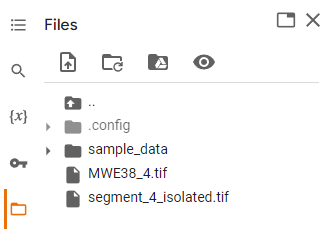

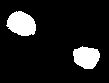

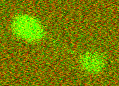

Reading image 20240307_MWE38_2_segmented_fix.tif


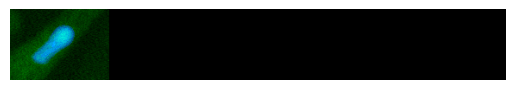

Output mesh at frame 6

Reading image 20240307_MWE38_1_segmented.tif
Output mesh at frame 7

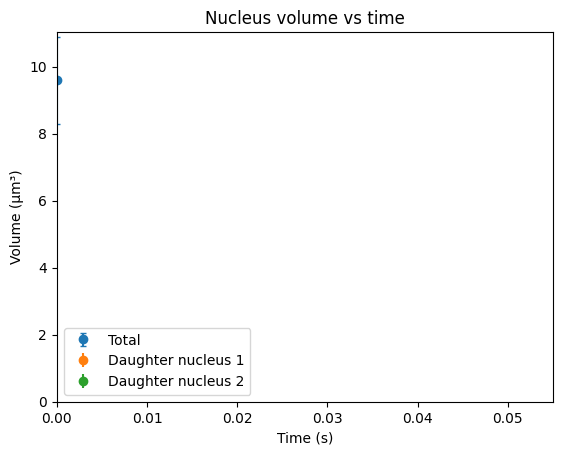

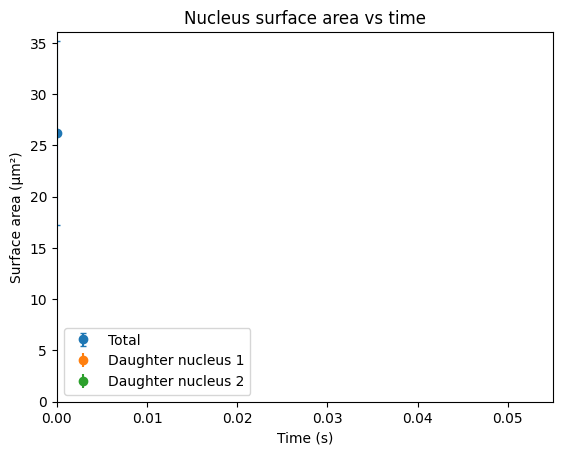

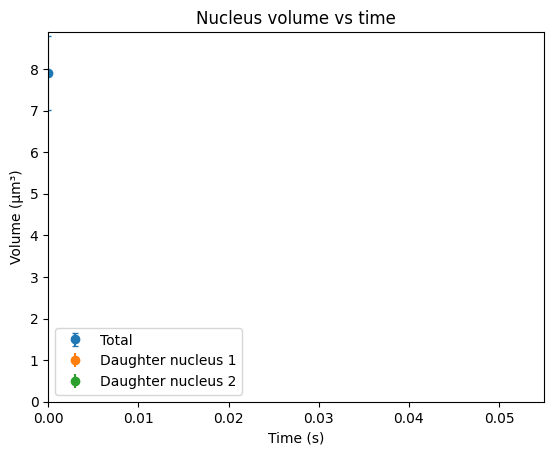

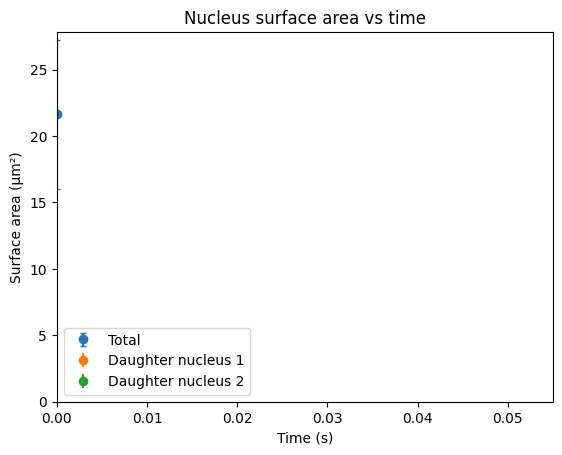

In [88]:
# List of file names of segmentation images in the format t,z,y,x.
# Note that the background should be black (0) and the forground should be white (255)
segmentedImages = ["20240307_MWE38_2_segmented_fix.tif","20240307_MWE38_1_segmented.tif"]

# List of file names of colored images in the format t,z,c,y,x. Pixel channel values can be any integer.
colorImages = ["20240307_MWE38_2.tif"]

# The width scale of the images in microns per pixel
xyscale=0.08

# The distance between layers of the z stack in microns
zscale=0.327

# 2D array the ranges of frames to process in terms of indexes. [start,stop). 0 is the first frame, -1 can be used to access the last frame.
tRanges = [[6,7],[7,8]]

#Number of seconds between frames
timeScale = 10

# Display a preview of each frame as a mesh
showMesh = True

# Save each frame as a .ply object
saveMesh = False

# If meshes are saved, include relative principal curvatures as vertex colors
useCurvature = False

# Subdivide and smooth meshes created with the in-house method.
doSubdivision = True

#======== End of user parameters =========

# Runs the program and stores the data from the graphs in 2 variables.
compareV,compareSA,compareL,fullData=ProcessManyCells(segmentedImages,colorImages,xyscale,zscale,tRanges)

# More Plots

In [36]:
#===== Saves data to a csv ======
import csv
def StringOrNone(input):
  if((type(input) is list or isinstance(input, np.ndarray) ) ):#if input is a non-empty list
    for i in range(len(input)):
      input[i] = StringOrNone(input[i])
    return(input)
  else:
    if(input == None):
      return(None)
    else:
      return(str(input))

#[cell_ID][value/error][Nucleus_ID][frame]
tscale=10
for cellId in range(len(fullData)):
  listVolume,listVolumeError,listSurfaceArea,listSurfaceAreaError,listLength,listNucleusCount,listNucleusCoords,listVFrus,listSAFrus,listPoleVector=fullData[cellId]
  #V = list(np.split(np.asarray(listVolume), 2, axis = 1))
  V = list(np.moveaxis(np.asarray(listVolume), 0, 1))
  V = ListOfArraysToList(V)
  #print(V)
  SA = list(np.moveaxis(np.asarray(listSurfaceArea), 0, 1))
  SA = ListOfArraysToList(SA)
  VFrus = list(np.moveaxis(np.asarray(listVFrus), 0, 1))
  VFrus = ListOfArraysToList(VFrus)
  SAFrus = list(np.moveaxis(np.asarray(listSAFrus), 0, 1))
  SAFrus = ListOfArraysToList(SAFrus)
  Length = list(np.moveaxis(np.asarray(listLength), 0, 1))
  Length = ListOfArraysToList(Length)
  Coords = (np.moveaxis(np.asarray(listNucleusCoords), 0, 2)).tolist()
  Vect = list(np.moveaxis(np.asarray(listPoleVector), 0, 1))
  Vect = ListOfArraysToList(Vect)
  #print(Coords)
  NucleusCount = listNucleusCount
  tempColumns = [ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  #d1,d2,og,total
  V=list(V)+[ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  SA=list(SA)+[ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  VFrus=list(VFrus)+[ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  SAFrus=list(SAFrus)+[ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  Length=list(Length)+[ (np.zeros(len(fullData[0][0]))).tolist() ,(np.zeros(len(fullData[0][0]))).tolist()]
  Coords=Coords+ np.zeros( (2,2,len(fullData[0][0])) ).tolist()
  #print(Coords)
  for i in range(len(fullData[0][0])):#for each frame
    if(int(NucleusCount[i])<2):#pre-split
      V[2][i]=V[0][i]#+V[1][i]#set og
      V[0][i]=None#d1
      V[1][i]=None#d2
      V[3][i]=None#total

      VFrus[2][i]=VFrus[0][i]+VFrus[1][i]#set og
      VFrus[0][i]=None#d1
      VFrus[1][i]=None#d2
      VFrus[3][i]=None#total

      SA[2][i]=SA[0][i]+SA[1][i]#set og
      SA[0][i]=None#d1
      SA[1][i]=None#d2
      SA[3][i]=None#total

      SAFrus[2][i]=SAFrus[0][i]+SAFrus[1][i]#set og
      SAFrus[0][i]=None#d1
      SAFrus[1][i]=None#d2
      SAFrus[3][i]=None#total

      Length[2][i]=Length[0][i]+Length[1][i]#set og
      Length[0][i]=None#d1
      Length[1][i]=None#d2
      Length[3][i]=None#total

      Coords[2][0][i]=Coords[0][0][i]#+Coords[1][0][i]#set og
      Coords[2][1][i]=Coords[0][1][i]#+Coords[1][1][i]#set og
      Coords[0][0][i]=None#d1
      Coords[0][1][i]=None#d1
      Coords[1][0][i]=None#d2
      Coords[1][1][i]=None#d2
      Coords[3][0][i]=None#total
      Coords[3][1][i]=None#total

    else:#split
      V[3][i]=V[0][i]+V[1][i]
      V[2][i]=None
      VFrus[3][i]=VFrus[0][i]+VFrus[1][i]
      VFrus[2][i]=None
      SA[3][i]=SA[0][i]+SA[1][i]
      SA[2][i]=None
      SAFrus[3][i]=SAFrus[0][i]+SAFrus[1][i]
      SAFrus[2][i]=None
      Length[3][i]=Length[0][i]+Length[1][i]
      Length[2][i]=None
      Coords[3][0][i]=Coords[0][0][i]+Coords[1][0][i]#set total
      Coords[3][1][i]=Coords[0][1][i]+Coords[1][1][i]#set total
      Coords[2][0][i]=None#d1
      Coords[2][1][i]=None#d1

  time = list(np.linspace(0,tscale*(len(fullData[0][0])-1),len(fullData[0][0])))

  headerCount = ['Nucleus Count']
  headerV = ['Original Volume (µm³)','D1 Volume (µm³)','D2 Volume (µm³)','Total Volume (µm³)']
  headerVFrus = ['Original Volume Estimation (µm³)','D1 Volume Estimation (µm³)','D2 Volume Estimation (µm³)','Total Volume Estimation (µm³)']
  headerSA = ['Original Surface Area (µm²)','D1 Surface Area (µm²)','D2 Surface Area (µm²)','Total Surface Area (µm²)']
  headerSAFrus = ['Original Surface Area Estimation (µm²)','D1 Surface Area Estimation (µm²)','D2 Surface Area Estimation (µm²)','Total Surface Area Estimation (µm²)']
  headerLength = ['Original Length (µm)','D1 Length (µm)','D2 Length (µm)','Total Length (µm)']
  headerCoords = ['Original x (µm)','Original y (µm)','D1 x (µm)','D1 y (µm)','D2 x (µm)','D2 y (µm)','Total x (µm)','Total y (µm)']
  headerVect = ['pole x','pole y','pole z']

  headers = ['Time (s)'] +headerCount+headerV+headerVFrus+headerSA+headerSAFrus+headerLength+headerCoords+headerVect

  rowsCount = [StringOrNone(NucleusCount)]
  rowsVect = [StringOrNone(Vect[0]),StringOrNone(Vect[1]),StringOrNone(Vect[2])]
  rowsV = [StringOrNone(V[2]),StringOrNone(V[0]),StringOrNone(V[1]),StringOrNone(V[3])]
  rowsVFrus = [StringOrNone(VFrus[2]),StringOrNone(VFrus[0]),StringOrNone(VFrus[1]),StringOrNone(VFrus[3])]
  rowsSA = [StringOrNone(SA[2]),StringOrNone(SA[0]),StringOrNone(SA[1]),StringOrNone(SA[3])]
  rowsSAFrus = [StringOrNone(SAFrus[2]),StringOrNone(SAFrus[0]),StringOrNone(SAFrus[1]),StringOrNone(SAFrus[3])]

  rowsLength = [StringOrNone(Length[2]),StringOrNone(Length[0]),StringOrNone(Length[1]),StringOrNone(Length[3])]
  rowsCoords = StringOrNone(Coords[2])+StringOrNone(Coords[0])+StringOrNone(Coords[1])+StringOrNone(Coords[3])
  #rowsCoords = (np.moveaxis(np.asarray(rowsCoords), 0, 1)).tolist()
  rows = [StringOrNone(time)]+rowsCount+rowsV+rowsVFrus+rowsSA+rowsSAFrus+rowsLength+rowsCoords+rowsVect
  #print(ListShape(rows))
  #print(rows)
  #"cp1252"
  #'UTF-8'
  rows = list( np.moveaxis(np.asarray(rows), 1, 0) )
  with open('20240307_MWE38_2.csv', 'w', encoding='UTF-8-sig', newline='') as csvarchive:
    writer = csv.writer(csvarchive)
    writer.writerow(headers)
    for i in range(len(rows)):
      writer.writerow(rows[i])
#MWE1, frames 27, 28, and one of the nuclei in 29 failed at depth 3.